# Forecasting Regional Two-Wheeler Demand in India with Neural Networks

**Goal:** build a model that reliably forecasts next year's two-wheeler demand for every
**region (State) × Brand × Model segment** combination, using neural networks built in
**Keras (TensorFlow)** and **PyTorch**.

**Data:** `data/bike_sales_india.csv` – 10,000 two-wheeler records across 10 Indian states,
8 brands and 40 models, with registration years 2015–2024.

## Contents
1. [Business understanding](#1.-Business-understanding)
2. [Setup](#2.-Setup)
3. [Data loading and data dictionary](#3.-Data-loading-and-data-dictionary)
4. [Data cleaning and feature preparation](#4.-Data-cleaning-and-feature-preparation)
5. [Exploratory data analysis](#5.-Exploratory-data-analysis)
6. [Inferential statistics](#6.-Inferential-statistics)
7. [Framing the forecasting problem](#7.-Framing-the-forecasting-problem)
8. [Evaluation metric and validation strategy](#8.-Evaluation-metric-and-validation-strategy)
9. [Baseline and classical models](#9.-Baseline-and-classical-models)
10. [Neural network 1 – Keras](#10.-Neural-network-1-–-Keras)
11. [Neural network 2 – PyTorch](#11.-Neural-network-2-–-PyTorch)
12. [Model comparison on the 2024 hold-out year](#12.-Model-comparison-on-the-2024-hold-out-year)
13. [Model interpretation](#13.-Model-interpretation)
14. [Forecast for 2025](#14.-Forecast-for-2025)
15. [Findings, recommendations and next steps](#15.-Findings,-recommendations-and-next-steps)

## 1. Business understanding

Two-wheeler manufacturers and dealer networks in India have to decide, **months in advance**,
how many units of each kind of bike to send to each state. Getting this wrong is expensive:

* **Over-supply** ties up working capital in dealer stock, forces discounting and raises warehousing cost.
* **Under-supply** loses sales to competing brands and frustrates customers on waiting lists.

The business question is therefore:

> *"How many units of each brand's commuter / scooter / cruiser / performance / adventure bikes
> will be registered in each state next year?"*

**How demand is measured here.** The dataset has no sales-date column, so we use the number of
vehicles **registered** in a given year as the demand signal. Each row is one bike, so counting rows per
`State × Brand × Segment × Registration Year` gives a yearly demand time series for every combination.

**Why neural networks?** We forecast 220 related time series at once. A neural network with
*embeddings* can share what it learns across all of them (for example, the national growth trend)
while still learning region-, brand- and segment-specific adjustments – something a separate
model per series cannot do with only ten years of history each.

## 2. Setup
Libraries are imported with their standard aliases. Random seeds are fixed so that results are
reproducible, and TensorFlow's start-up logging is silenced to keep the notebook output short.

In [2]:
!pip install numpy pandas scipy matplotlib seaborn scikit-learn torch tensorflow

     |████████████████████████████████| 73.6 MB 8.0 MB/s eta 0:00:015
     |████████████████████████████████| 200.4 MB 21.4 MB/s eta 0:00:01
     |████████████████████████████████| 1.6 MB 9.5 MB/s eta 0:00:01
  Using cached fsspec-2025.10.0-py3-none-any.whl (200 kB)
  Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
  Using cached filelock-3.19.1-py3-none-any.whl (15 kB)
     |████████████████████████████████| 135 kB 29.1 MB/s eta 0:00:01
     |████████████████████████████████| 427 kB 6.0 MB/s eta 0:00:01
  Using cached google_pasta-0.2.0-py3-none-any.whl (57 kB)
     |████████████████████████████████| 676 kB 8.1 MB/s eta 0:00:01
  Using cached gast-0.7.0-py3-none-any.whl (22 kB)
     |████████████████████████████████| 1.4 MB 12.7 MB/s eta 0:00:01
     |████████████████████████████████| 5.5 MB 10.0 MB/s eta 0:00:01
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl (26 kB)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl (25.8 MB)
     |█████████████████████

In [ ]:
# --- Standard library ---------------------------------------------------------
import os
import random
import warnings
from itertools import product
from pathlib import Path

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"      # hide TensorFlow C++ start-up messages
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"     # hide the oneDNN notice and keep results reproducible
warnings.filterwarnings("ignore")

# --- Data handling and statistics ---------------------------------------------
import numpy as np
import pandas as pd
from scipy import stats

# --- Visualisation --------------------------------------------------------------
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# --- Classical machine learning (scikit-learn) ----------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import PoissonRegressor, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler

# --- Deep learning: PyTorch -----------------------------------------------------
# PyTorch is imported *before* TensorFlow: loading them in the opposite order can crash
# the kernel on some systems because both ship their own native libraries.
import torch
import torch._dynamo  # noqa: F401  (pre-loads a module the Adam optimiser imports lazily)
from torch import nn

# --- Deep learning: Keras (TensorFlow back-end) ---------------------------------
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel("ERROR")

# --- Reproducibility ------------------------------------------------------------
SEED = 42
def set_seed(seed: int = SEED) -> None:
    """Fix every random number generator used in the notebook."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)

set_seed()
torch.set_num_threads(2)

# --- Plot style -------------------------------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({"figure.dpi": 100, "axes.titleweight": "bold", "axes.titlesize": 13})
pd.set_option("display.precision", 2)

print(f"pandas {pd.__version__} | TensorFlow {tf.__version__} | Keras {keras.__version__} | PyTorch {torch.__version__}")

## 3. Data loading and data dictionary

In [2]:
# The CSV is expected in a `data/` folder next to this notebook.
DATA_PATH = Path("data") / "bike_sales_india.csv"
bikes_raw = pd.read_csv(DATA_PATH)

print(f"Rows: {bikes_raw.shape[0]:,} | Columns: {bikes_raw.shape[1]}")
bikes_raw.head()

Rows: 10,000 | Columns: 15


,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


| Column | Type | Description |
|---|---|---|
| State | categorical | Indian state where the bike is registered (**region**) |
| Avg Daily Distance (km) | continuous | Average distance ridden per day |
| Brand | categorical | Manufacturer (8 brands) |
| Model | categorical | Model name (40 models, 5 per brand) |
| Price (INR) | continuous | Original purchase price |
| Year of Manufacture | discrete | Year the bike was built |
| Engine Capacity (cc) | continuous | Engine displacement |
| Fuel Type | categorical | Petrol / Electric / Hybrid |
| Mileage (km/l) | continuous | Fuel efficiency |
| Owner Type | categorical | First / Second / Third owner |
| Registration Year | discrete | Year the bike was registered – **our time axis for demand** |
| Insurance Status | categorical | Active / Expired / Not Available |
| Seller Type | categorical | Dealer / Individual |
| Resale Price (INR) | continuous | Current resale value |
| City Tier | categorical | Metro / Tier 1 / Tier 2 / Tier 3 |

In [3]:
bikes_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State                    10000 non-null  str    
 1   Avg Daily Distance (km)  10000 non-null  float64
 2   Brand                    10000 non-null  str    
 3   Model                    10000 non-null  str    
 4   Price (INR)              10000 non-null  int64  
 5   Year of Manufacture      10000 non-null  int64  
 6   Engine Capacity (cc)     10000 non-null  int64  
 7   Fuel Type                10000 non-null  str    
 8   Mileage (km/l)           10000 non-null  float64
 9   Owner Type               10000 non-null  str    
 10  Registration Year        10000 non-null  int64  
 11  Insurance Status         10000 non-null  str    
 12  Seller Type              10000 non-null  str    
 13  Resale Price (INR)       10000 non-null  float64
 14  City Tier                10000 non

## 4. Data cleaning and feature preparation

### 4.1 Data-quality checks
We check for missing values, duplicate rows, inconsistent text labels and logically impossible
values (for example, a bike registered before it was manufactured).

In [4]:
bikes = bikes_raw.copy()

# Tidy column names into snake_case so they are easy to type in code
bikes.columns = (bikes.columns.str.lower()
                 .str.replace(r"\s*\(.*\)", "", regex=True)   # drop units in brackets
                 .str.strip()
                 .str.replace(" ", "_"))

# Strip stray whitespace from every text column
text_cols = bikes.select_dtypes(include=["object", "string"]).columns
for col in text_cols:
    bikes[col] = bikes[col].str.strip()

quality_report = pd.DataFrame({
    "missing_values": bikes.isna().sum(),
    "unique_values": bikes.nunique(),
    "dtype": bikes.dtypes.astype(str),
})
print(f"Duplicate rows: {bikes.duplicated().sum()}")
quality_report

Duplicate rows: 0


,missing_values,unique_values,dtype
state,0,10,str
avg_daily_distance,0,5535,float64
brand,0,8,str
model,0,40,str
price,0,9863,int64
year_of_manufacture,0,10,int64
engine_capacity,0,901,int64
fuel_type,0,3,str
mileage,0,5404,float64
owner_type,0,3,str


In [5]:
# Logical consistency checks
registered_before_built = (bikes["registration_year"] < bikes["year_of_manufacture"]).sum()
non_positive_prices = (bikes[["price", "resale_price"]] <= 0).sum().sum()
resale_above_price = (bikes["resale_price"] > bikes["price"]).sum()

print(f"Registered before manufacture : {registered_before_built}")
print(f"Non-positive prices           : {non_positive_prices}")
print(f"Resale price above new price  : {resale_above_price}")

Registered before manufacture : 0
Non-positive prices           : 0
Resale price above new price  : 0


**Result:** no missing values, no duplicates and no logically impossible records, so no rows need
to be removed. Text labels are already consistent (e.g. exactly 10 states, 8 brands, 40 models).

### 4.2 Is `Engine Capacity` a reliable way to define the model segment?
A natural idea is to segment bikes by engine size. Before doing so we check whether engine capacity is
consistent **within** a model – a Honda Activa should always have roughly the same engine.

In [6]:
cc_by_model = (bikes.groupby("model")["engine_capacity"]
               .agg(["min", "median", "max", "std"])
               .sort_values("std", ascending=False))
cc_by_model.head(8)

,min,median,max,std
model,,,,
Glamour,102,590.5,998,277.96
CBR 650R,102,584.5,991,274.81
Versys 650,105,566.0,999,271.77
Z650,103,535.0,999,271.37
Hunter 350,102,610.0,1000,270.14
RC 390,100,528.5,1000,269.51
Ninja 300,104,590.0,998,269.46
Fascino 125,105,576.0,1000,266.68


Engine capacity varies from about 100 cc to 1,000 cc *within the same model* (a standard deviation of
~260 cc for every model), so this column is noisy and cannot define a segment. Instead, each model is
mapped to its **market segment** using the manufacturer's own positioning of the model in India:

* **Commuter** – fuel-efficient everyday motorcycles (Splendor Plus, Shine, Platina…)
* **Scooter** – gearless scooters (Activa, Jupiter, NTorq…)
* **Cruiser** – relaxed-riding retro and cruiser bikes (Classic 350, Meteor 350, Vulcan S…)
* **Performance** – sport, naked and faired bikes (Duke, Ninja, R15, Apache…)
* **Adventure / Touring** – long-distance and off-road capable bikes (Himalayan, 390 Adventure, Versys 650)

In [7]:
MODEL_SEGMENT = {
    # Bajaj
    "CT 100": "Commuter", "Platina 110": "Commuter", "Pulsar 150": "Commuter",
    "Avenger 220": "Cruiser", "Dominar 400": "Performance",
    # Hero
    "Splendor Plus": "Commuter", "HF Deluxe": "Commuter", "Passion Pro": "Commuter",
    "Glamour": "Commuter", "Xtreme 160R": "Performance",
    # Honda
    "Shine": "Commuter", "Unicorn": "Commuter", "Activa": "Scooter", "Dio": "Scooter",
    "CBR 650R": "Performance",
    # KTM
    "125 Duke": "Performance", "Duke 200": "Performance", "250 Duke": "Performance",
    "RC 390": "Performance", "390 Adventure": "Adventure/Touring",
    # Kawasaki
    "Ninja 300": "Performance", "Ninja 400": "Performance", "Z650": "Performance",
    "Vulcan S": "Cruiser", "Versys 650": "Adventure/Touring",
    # Royal Enfield
    "Classic 350": "Cruiser", "Hunter 350": "Cruiser", "Meteor 350": "Cruiser",
    "Interceptor 650": "Cruiser", "Himalayan": "Adventure/Touring",
    # TVS
    "Sport": "Commuter", "Jupiter": "Scooter", "NTorq 125": "Scooter",
    "Apache RTR 160": "Performance", "Ronin": "Cruiser",
    # Yamaha
    "FZ V3": "Commuter", "Fascino 125": "Scooter", "Ray ZR": "Scooter",
    "MT-15": "Performance", "R15 V4": "Performance",
}

bikes["segment"] = bikes["model"].map(MODEL_SEGMENT)
assert bikes["segment"].notna().all(), "Every model must have a segment"

SEGMENT_ORDER = ["Commuter", "Scooter", "Cruiser", "Performance", "Adventure/Touring"]
TIER_ORDER = ["Metro", "Tier 1", "Tier 2", "Tier 3"]

# Convert low-cardinality text columns to ordered categoricals (memory-efficient and sorts nicely)
bikes["segment"] = pd.Categorical(bikes["segment"], categories=SEGMENT_ORDER, ordered=True)
bikes["city_tier"] = pd.Categorical(bikes["city_tier"], categories=TIER_ORDER, ordered=True)
bikes["owner_type"] = pd.Categorical(bikes["owner_type"], categories=["First", "Second", "Third"], ordered=True)

# Useful derived variables
bikes["age_at_registration"] = bikes["registration_year"] - bikes["year_of_manufacture"]
bikes["resale_ratio"] = bikes["resale_price"] / bikes["price"]

pd.crosstab(bikes["brand"], bikes["segment"], margins=True, margins_name="Total")

segment,Commuter,Scooter,Cruiser,Performance,Adventure/Touring,Total
brand,,,,,,
Bajaj,725,0,249,233,0,1207
Hero,990,0,0,249,0,1239
Honda,501,472,0,248,0,1221
KTM,0,0,0,1018,254,1272
Kawasaki,0,0,267,763,261,1291
Royal Enfield,0,0,1004,0,249,1253
TVS,258,497,252,227,0,1234
Yamaha,256,527,0,500,0,1283
Total,2730,1496,1772,3238,764,10000


Brand portfolios differ: Hero is almost entirely commuters, Kawasaki and KTM are performance-led,
Royal Enfield is cruiser-led. So not every brand competes in every segment – the forecasting panel
will only include the **State × Brand × Segment** combinations that actually exist.

## 5. Exploratory data analysis

### 5.1 Categorical variables

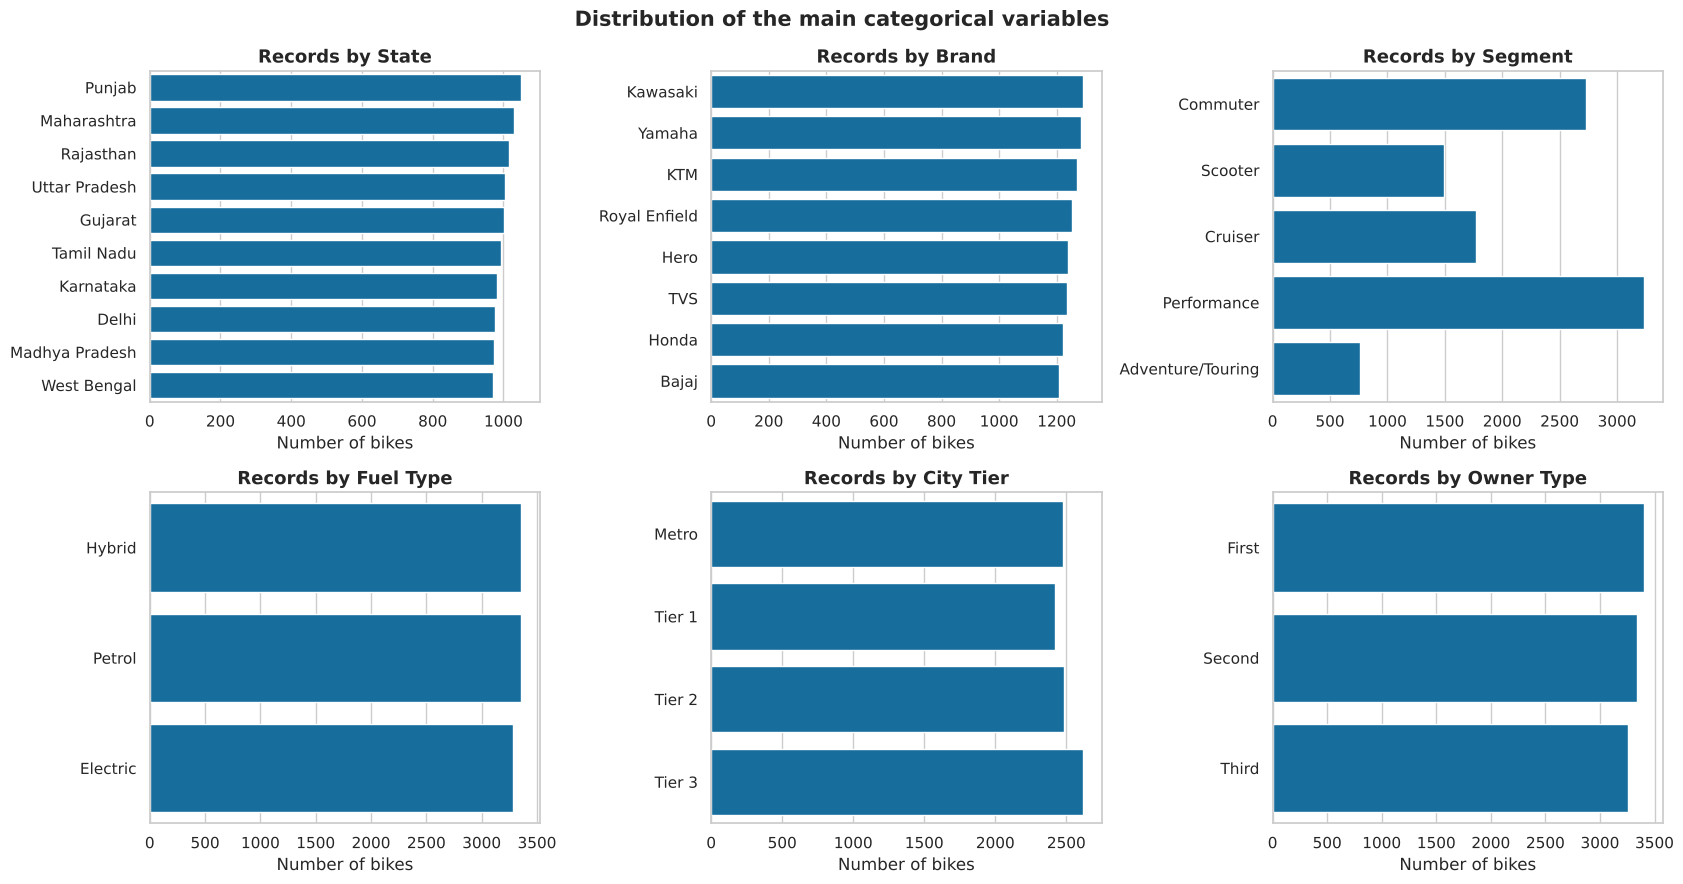

In [8]:
cat_vars = ["state", "brand", "segment", "fuel_type", "city_tier", "owner_type"]
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for ax, col in zip(axes.flat, cat_vars):
    order = (bikes[col].cat.categories if isinstance(bikes[col].dtype, pd.CategoricalDtype)
             else bikes[col].value_counts().index)
    sns.countplot(data=bikes, y=col, order=order, color=PALETTE[0], ax=ax)
    ax.set_title(f"Records by {col.replace('_', ' ').title()}")
    ax.set_xlabel("Number of bikes")
    ax.set_ylabel("")

fig.suptitle("Distribution of the main categorical variables", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

* States, brands, fuel types and city tiers are **almost evenly represented** (each state ≈ 1,000 records).
* **Commuter** and **Performance** are the biggest segments; **Adventure/Touring** is the smallest
  because only three models belong to it.

### 5.2 Continuous variables

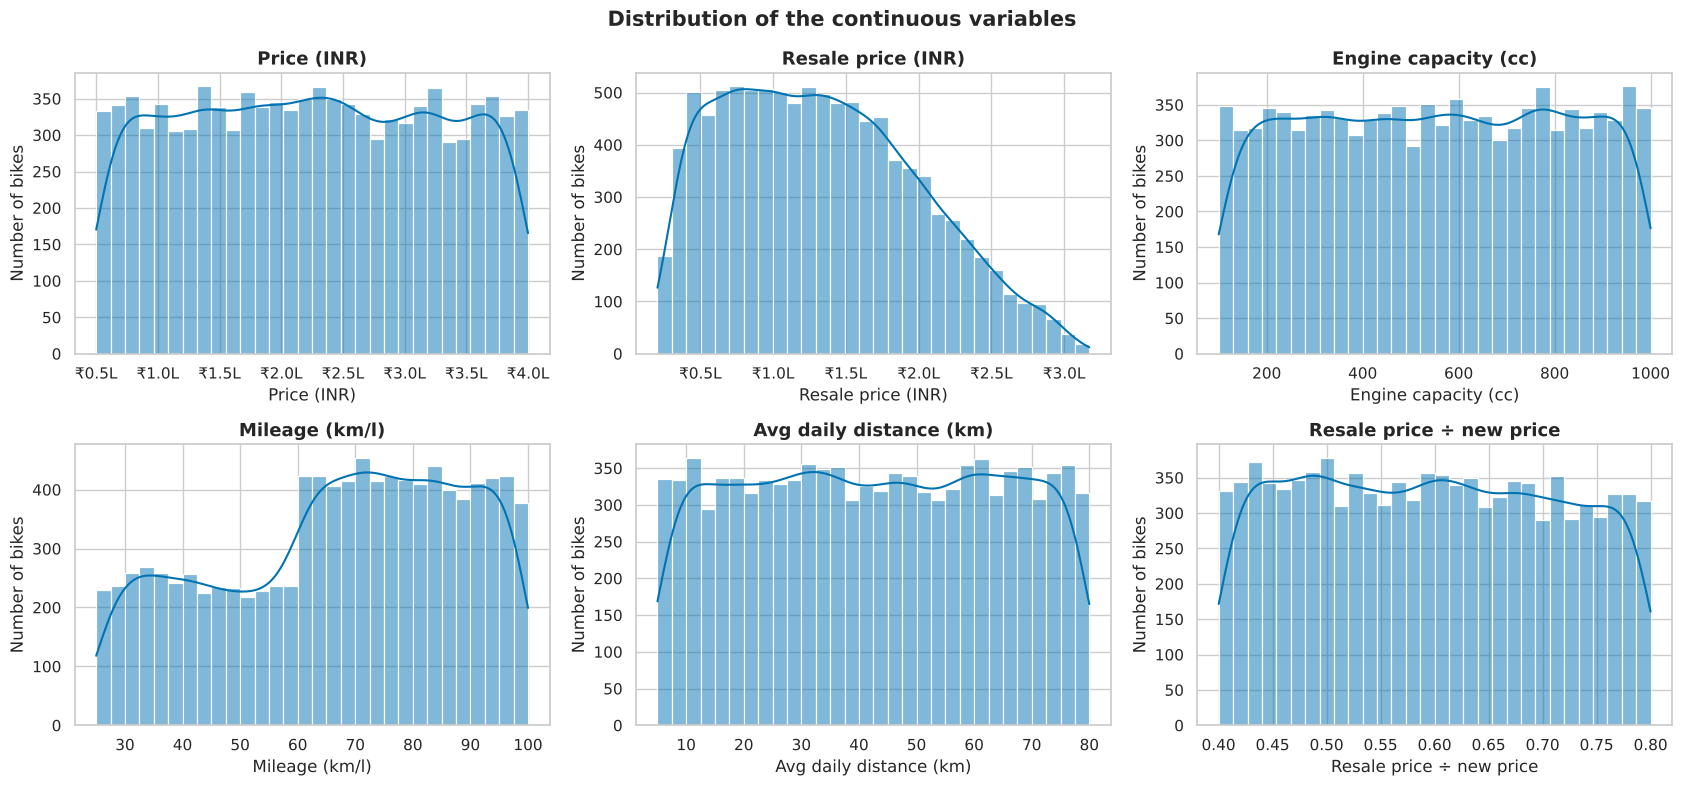

In [9]:
num_vars = {"price": "Price (INR)", "resale_price": "Resale price (INR)",
            "engine_capacity": "Engine capacity (cc)", "mileage": "Mileage (km/l)",
            "avg_daily_distance": "Avg daily distance (km)", "resale_ratio": "Resale price ÷ new price"}

fig, axes = plt.subplots(2, 3, figsize=(17, 8))
for ax, (col, label) in zip(axes.flat, num_vars.items()):
    sns.histplot(bikes[col], bins=30, kde=True, color=PALETTE[0], ax=ax)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Number of bikes")
    if "price" in col:
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e5:.1f}L"))

fig.suptitle("Distribution of the continuous variables", fontsize=15, fontweight="bold")
fig.tight_layout()
plt.show()

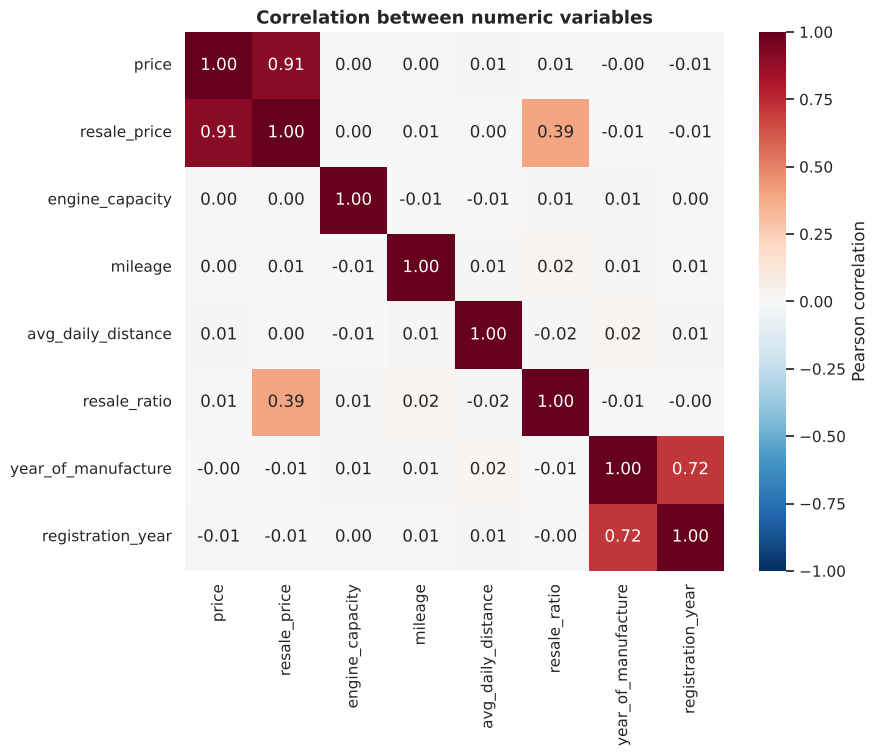

In [10]:
corr = bikes[list(num_vars) + ["year_of_manufacture", "registration_year"]].corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, cbar_kws={"label": "Pearson correlation"}, ax=ax)
ax.set_title("Correlation between numeric variables")
plt.show()

* Prices are spread fairly uniformly between ₹50k and ₹4 lakh; resale value is typically 40–80 % of the new price.
* The only strong relationship is **price ↔ resale price (r ≈ 0.91)**. Engine size, mileage and
  distance are essentially uncorrelated with price, confirming that these product attributes are noisy
  and should not drive the demand model.

### 5.3 How has demand changed over time?

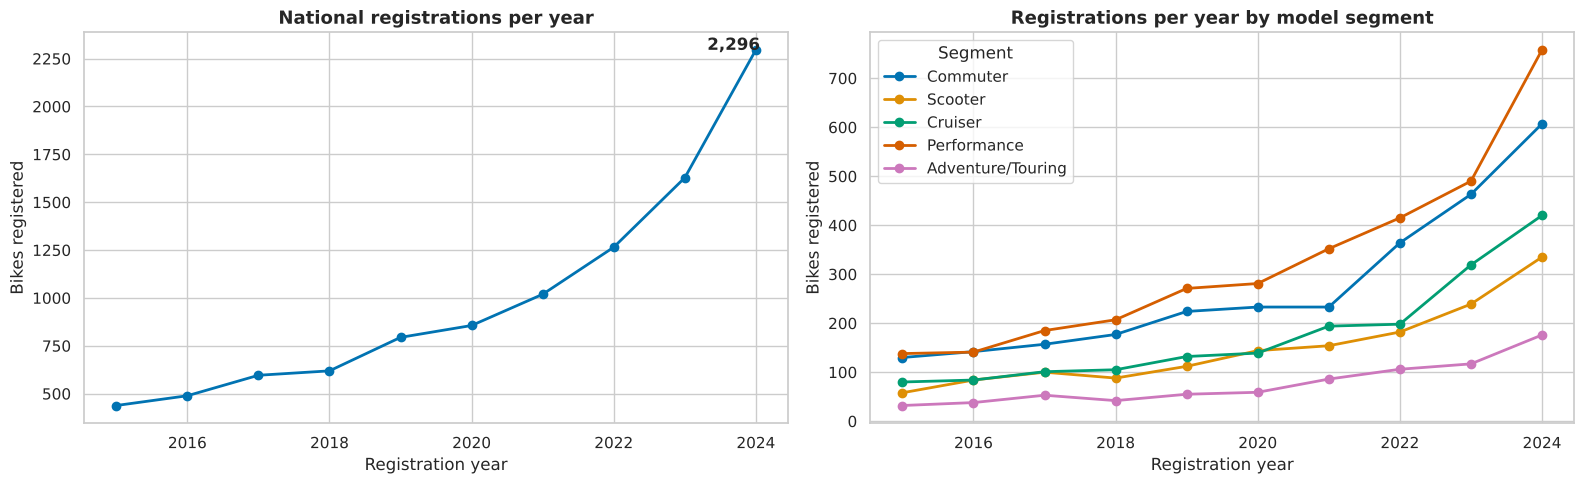

registration_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
registrations,438.0,489.0,596.0,619.0,794.0,856.0,1019.0,1265.0,1628.0,2296.0
YoY growth %,NaN,11.6,21.9,3.9,28.3,7.8,19.0,24.1,28.7,41.0


In [11]:
yearly = bikes.groupby("registration_year").size()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(yearly.index, yearly.values, marker="o", linewidth=2, color=PALETTE[0])
axes[0].set_title("National registrations per year")
axes[0].set_xlabel("Registration year")
axes[0].set_ylabel("Bikes registered")
axes[0].annotate(f"{yearly.iloc[-1]:,}", (yearly.index[-1], yearly.iloc[-1]),
                 textcoords="offset points", xytext=(-35, 0), fontweight="bold")

seg_year = (bikes.groupby(["registration_year", "segment"], observed=True).size()
            .unstack("segment"))
seg_year.plot(ax=axes[1], marker="o", linewidth=2, color=PALETTE[:len(SEGMENT_ORDER)])
axes[1].set_title("Registrations per year by model segment")
axes[1].set_xlabel("Registration year")
axes[1].set_ylabel("Bikes registered")
axes[1].legend(title="Segment")

fig.tight_layout()
plt.show()

growth = yearly.pct_change().mul(100).round(1).rename("YoY growth %")
pd.concat([yearly.rename("registrations"), growth], axis=1).T

Registrations grow **every single year** – from 438 in 2015 to 2,296 in 2024 (≈5×), with growth
accelerating to +29 % in 2023 and +41 % in 2024. All five segments follow the same upward curve.
**The national trend is the single most important signal for forecasting next year.**

### 5.4 Regional and brand patterns

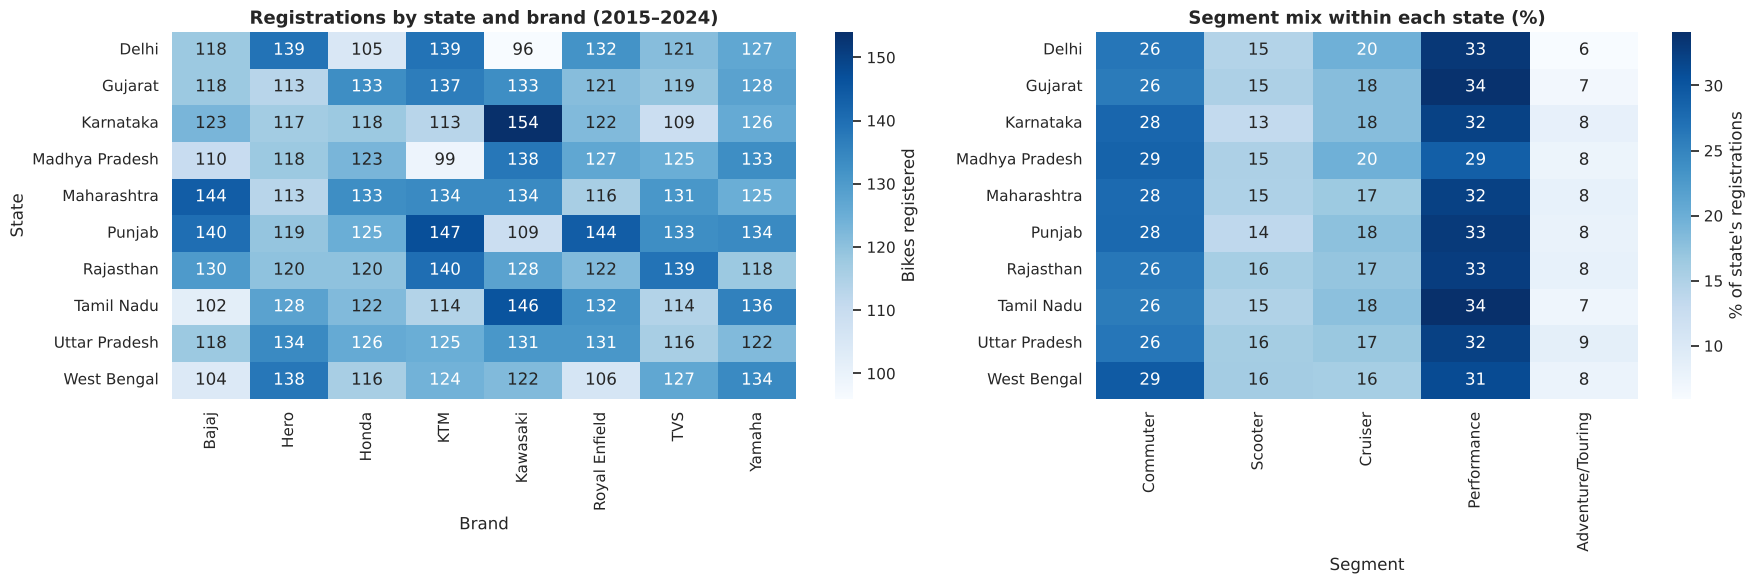

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={"width_ratios": [1.15, 1]})

state_brand = pd.crosstab(bikes["state"], bikes["brand"])
sns.heatmap(state_brand, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Bikes registered"}, ax=axes[0])
axes[0].set_title("Registrations by state and brand (2015–2024)")
axes[0].set_xlabel("Brand")
axes[0].set_ylabel("State")

state_segment = pd.crosstab(bikes["state"], bikes["segment"], normalize="index").mul(100)
sns.heatmap(state_segment, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "% of state's registrations"}, ax=axes[1])
axes[1].set_title("Segment mix within each state (%)")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("")

fig.tight_layout()
plt.show()

Brand and segment shares look very similar from state to state (e.g. Commuter is ~30 % of
registrations everywhere). Section 6 tests formally whether these differences are real or just noise.

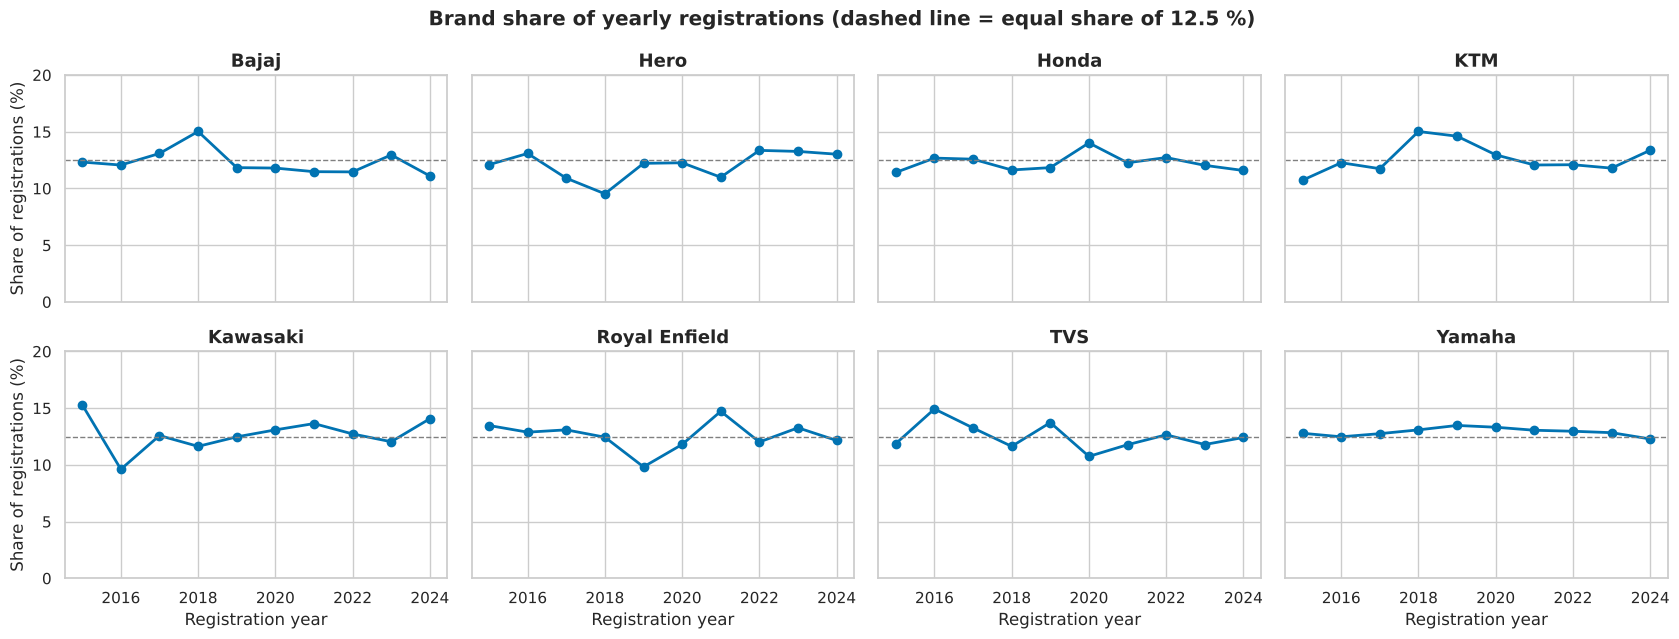

In [13]:
# Brand share trend: has any brand gained or lost share over time?
brand_share = pd.crosstab(bikes["registration_year"], bikes["brand"], normalize="index").mul(100)

# One small panel per brand (easier to read than eight overlapping lines)
fig, axes = plt.subplots(2, 4, figsize=(17, 6.5), sharex=True, sharey=True)
for ax, brand in zip(axes.flat, brand_share.columns):
    ax.plot(brand_share.index, brand_share[brand], marker="o", linewidth=2, color=PALETTE[0])
    ax.axhline(100 / brand_share.shape[1], color="grey", linestyle="--", linewidth=1)
    ax.set_title(brand)
    ax.set_ylim(0, 20)
for ax in axes[:, 0]:
    ax.set_ylabel("Share of registrations (%)")
for ax in axes[-1, :]:
    ax.set_xlabel("Registration year")
fig.suptitle("Brand share of yearly registrations (dashed line = equal share of 12.5 %)", fontweight="bold")
fig.tight_layout()
plt.show()

Brand shares move around 12.5 % (= 1 ÷ 8 brands) and the swings are largest in the early years,
where yearly volumes are small. There is no brand with a clear, sustained gain or loss of share.

### 5.5 Market context: price, fuel type and city tier by segment

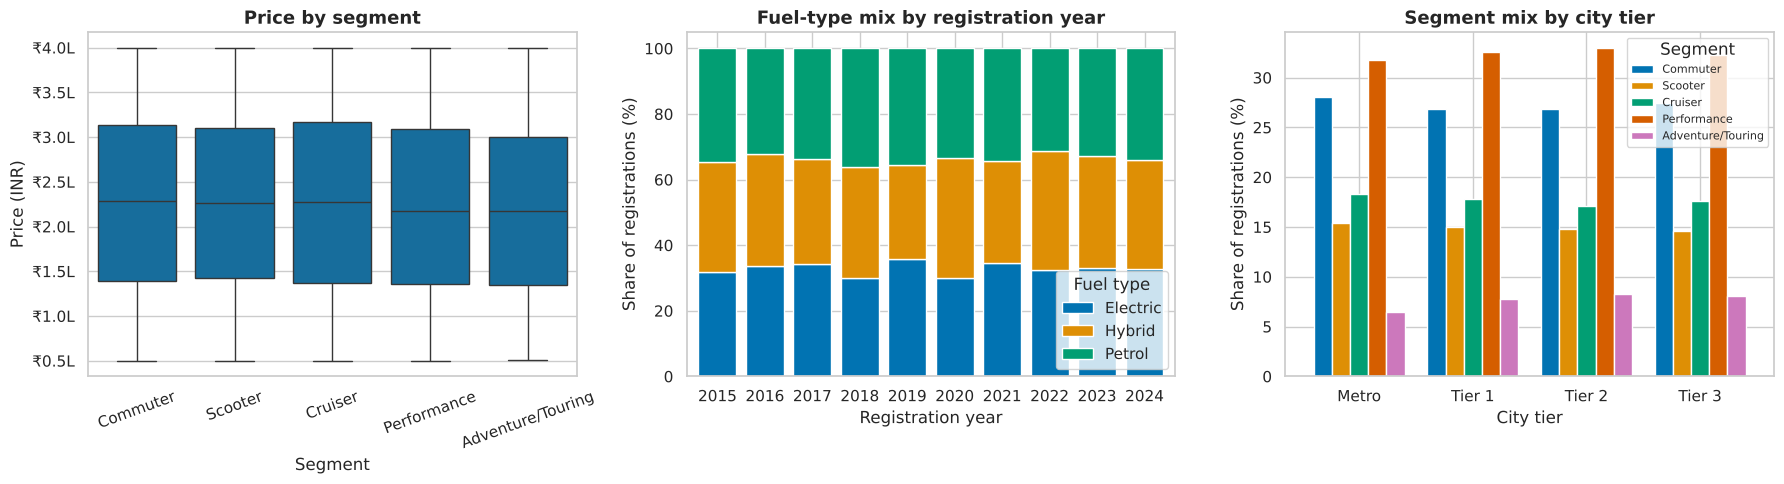

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=bikes, x="segment", y="price", order=SEGMENT_ORDER, color=PALETTE[0], ax=axes[0])
axes[0].set_title("Price by segment")
axes[0].set_xlabel("Segment")
axes[0].set_ylabel("Price (INR)")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"₹{x/1e5:.1f}L"))
axes[0].tick_params(axis="x", rotation=20)

fuel_mix = pd.crosstab(bikes["registration_year"], bikes["fuel_type"], normalize="index").mul(100)
fuel_mix.plot(kind="bar", stacked=True, ax=axes[1], color=PALETTE[:3], width=0.8, edgecolor="white")
axes[1].set_title("Fuel-type mix by registration year")
axes[1].set_xlabel("Registration year")
axes[1].set_ylabel("Share of registrations (%)")
axes[1].legend(title="Fuel type", loc="lower right")
axes[1].tick_params(axis="x", rotation=0)

tier_seg = pd.crosstab(bikes["city_tier"], bikes["segment"], normalize="index").mul(100)
tier_seg.plot(kind="bar", ax=axes[2], color=PALETTE[:len(SEGMENT_ORDER)], width=0.8)
axes[2].set_title("Segment mix by city tier")
axes[2].set_xlabel("City tier")
axes[2].set_ylabel("Share of registrations (%)")
axes[2].legend(title="Segment", fontsize=8)
axes[2].tick_params(axis="x", rotation=0)

fig.tight_layout()
plt.show()

* The *price* distribution is the same across segments – another sign that the product attributes in this
  dataset are not tied to the model, so they are excluded from the demand model.
* Electric, hybrid and petrol each account for about a third of registrations every year.
* The segment mix is almost identical in Metro, Tier 1, Tier 2 and Tier 3 cities.

## 6. Inferential statistics
The charts suggest (a) a strong national growth trend and (b) stable regional and brand mixes. We test
both formally at the 5 % significance level.

In [15]:
# Test 1 – Is the yearly growth trend statistically significant?
# A straight line on log(registrations) vs year gives the compound annual growth rate (CAGR).
trend = stats.linregress(yearly.index, np.log(yearly.values))
cagr = np.exp(trend.slope) - 1
ci_low, ci_high = np.exp(trend.slope + np.array([-1, 1]) * stats.t.ppf(0.975, len(yearly) - 2) * trend.stderr) - 1
print(f"Compound annual growth rate: {cagr:.1%} (95% CI {ci_low:.1%} to {ci_high:.1%}), "
      f"R² = {trend.rvalue**2:.3f}, p-value = {trend.pvalue:.1e}")

Compound annual growth rate: 19.0% (95% CI 16.0% to 22.0%), R² = 0.969, p-value = 2.6e-07


In [16]:
def chi_square_test(row_var: str, col_var: str, data: pd.DataFrame = bikes) -> dict:
    """Chi-square test of independence between two categorical variables plus Cramér's V effect size."""
    table = pd.crosstab(data[row_var], data[col_var])
    chi2, p_value, dof, _ = stats.chi2_contingency(table)
    cramers_v = np.sqrt(chi2 / (table.values.sum() * (min(table.shape) - 1)))
    return {"variables": f"{row_var} × {col_var}", "chi2": round(chi2, 1), "dof": dof,
            "p_value": round(p_value, 4), "cramers_v": round(cramers_v, 3),
            "significant (5%)": p_value < 0.05}

tests = [("state", "brand"), ("state", "segment"), ("city_tier", "segment"),
         ("registration_year", "brand"), ("registration_year", "segment"), ("registration_year", "state")]
pd.DataFrame([chi_square_test(a, b) for a, b in tests])

,variables,chi2,dof,p_value,cramers_v,significant (5%)
0,state × brand,73.3,63,0.18,0.03,False
1,state × segment,31.6,36,0.68,0.03,False
2,city_tier × segment,9.1,12,0.69,0.02,False
3,registration_year × brand,61.4,63,0.53,0.03,False
4,registration_year × segment,41.9,36,0.23,0.03,False
5,registration_year × state,75.5,81,0.65,0.03,False


**Interpretation**

* **Growth trend:** demand grows at roughly **19 % per year** (95 % confidence interval 16–22 %) and the
  trend is highly significant (p < 0.001, R² ≈ 0.97). A good forecast must project this growth forward rather than simply repeat last year.
* **Regional and brand mixes:** none of the chi-square tests is significant (all p-values > 0.05), and
  Cramér's V is tiny (< 0.05, where 0.1 would be a "small" effect). In plain words: **each state's
  preference for brands and segments is statistically the same, and these shares have not shifted over
  time.** The differences seen in the heatmaps are random noise.

**What this means for modelling:** the best forecast for a State × Brand × Segment cell is roughly
*"its stable long-run share of the market × next year's national volume"*. Year-to-year swings in a single
small cell are mostly noise, so a model that over-reacts to last year's number will be penalised.

## 7. Framing the forecasting problem

### 7.1 Build the demand panel
We count registrations for every **State × Brand × Segment** cell in every year. Cells with no
registrations in a year get an explicit **0** (a zero is real information about demand). An extra,
empty row for **2025** is added to each cell so the same feature code can later produce the 2025 forecast.

In [17]:
KEYS = ["state", "brand", "segment"]
FIRST_YEAR, LAST_YEAR, FORECAST_YEAR = 2015, 2024, 2025

demand_counts = (bikes.groupby(KEYS + ["registration_year"], observed=True)
                 .size().rename("units").reset_index())

existing_cells = bikes[KEYS].drop_duplicates()
all_years = pd.DataFrame({"registration_year": range(FIRST_YEAR, FORECAST_YEAR + 1)})
panel = (existing_cells.merge(all_years, how="cross")
         .merge(demand_counts, on=KEYS + ["registration_year"], how="left"))

# Missing counts in observed years are true zeros; 2025 stays NaN because it is the future.
observed = panel["registration_year"] <= LAST_YEAR
panel.loc[observed, "units"] = panel.loc[observed, "units"].fillna(0)
panel = panel.sort_values(KEYS + ["registration_year"]).reset_index(drop=True)
for col in KEYS:
    panel[col] = panel[col].astype(str)

n_cells = panel[KEYS].drop_duplicates().shape[0]
print(f"Forecasting cells (State × Brand × Segment): {n_cells}")
print(f"Panel rows: {len(panel):,}  ({n_cells} cells × {all_years.shape[0]} years)")
panel[observed].describe()[["units"]].T

Forecasting cells (State × Brand × Segment): 220
Panel rows: 2,420  (220 cells × 11 years)


,count,mean,std,min,25%,50%,75%,max
units,2200.0,4.55,4.57,0.0,2.0,3.0,6.0,35.0


There are **220 cells** (10 states × the brand-segment combinations that exist). The average cell sells
about 4.5 units a year (≈ 10 in 2024), so individual cells are small and naturally noisy.

### 7.2 Feature engineering (no look-ahead)
Every feature for year *t* is calculated **only from years before t**, exactly as it would be in real
life when planning next year's allocation:

| Feature | Meaning |
|---|---|
| `lag_1`, `lag_2`, `lag_3` | the cell's units 1, 2 and 3 years earlier |
| `rolling_mean_3` | average of the last three years |
| `cell_history_mean` | average of all previous years for this cell |
| `cell_share` | cell's share of national registrations over all previous years (the "stable share") |
| `national_lag_1`, `national_growth` | last year's national total and last year's national growth rate |
| `national_trend_forecast` | national total for year *t* projected from the log-linear trend of previous years |
| `share_x_trend` | `cell_share × national_trend_forecast` – a hand-crafted "expected units" signal |
| `state_lag_1`, `brand_lag_1`, `segment_lag_1` | last year's totals for the cell's state, brand and segment |
| `years_since_start` | time index |
| `state`, `brand`, `segment` | categorical identifiers (one-hot or embeddings in the models) |

In [18]:
def national_trend_projection(national_series: pd.Series) -> pd.Series:
    """For each year t, fit a log-linear trend on years < t (minimum three) and project year t."""
    projections = {}
    years = national_series.index
    for target_year in years:
        history = national_series[(years < target_year) & national_series.notna()]
        if len(history) >= 3:
            slope, intercept = np.polyfit(history.index, np.log(history.values), 1)
            projections[target_year] = np.exp(intercept + slope * target_year)
    return pd.Series(projections)


def build_features(panel_df: pd.DataFrame) -> pd.DataFrame:
    """Create leak-free lag, share and trend features for every cell-year."""
    df = panel_df.copy()
    cell_units = df.groupby(KEYS)["units"]

    # Cell-level history
    for lag in (1, 2, 3):
        df[f"lag_{lag}"] = cell_units.shift(lag)
    df["rolling_mean_3"] = df[["lag_1", "lag_2", "lag_3"]].mean(axis=1)
    df["cell_history_mean"] = cell_units.transform(lambda s: s.shift(1).expanding().mean())
    df["cell_history_total"] = cell_units.transform(lambda s: s.shift(1).expanding().sum())

    # National history and trend projection
    national = df.groupby("registration_year")["units"].sum(min_count=1)
    national_cum = national.shift(1).cumsum()
    df["national_lag_1"] = df["registration_year"].map(national.shift(1))
    df["national_growth"] = df["registration_year"].map(national.shift(1) / national.shift(2))
    df["national_trend_forecast"] = df["registration_year"].map(national_trend_projection(national))
    df["cell_share"] = df["cell_history_total"] / df["registration_year"].map(national_cum)
    df["share_x_trend"] = df["cell_share"] * df["national_trend_forecast"]

    # Last year's totals for the cell's state, brand and segment
    for key in KEYS:
        group_total = df.groupby([key, "registration_year"])["units"].sum(min_count=1)
        group_lag = group_total.groupby(level=0).shift(1).rename(f"{key}_lag_1").reset_index()
        df = df.merge(group_lag, on=[key, "registration_year"], how="left")

    df["years_since_start"] = df["registration_year"] - FIRST_YEAR
    return df.drop(columns="cell_history_total")


features_df = build_features(panel)

# The first three years are needed to create lag_3 and the trend projection, so modelling starts in 2018.
model_df = features_df[features_df["registration_year"] >= 2018].reset_index(drop=True)

NUMERIC_FEATURES = ["lag_1", "lag_2", "lag_3", "rolling_mean_3", "cell_history_mean", "cell_share",
                    "national_lag_1", "national_growth", "national_trend_forecast", "share_x_trend",
                    "state_lag_1", "brand_lag_1", "segment_lag_1", "years_since_start"]
CATEGORICAL_FEATURES = KEYS
TARGET = "units"

assert model_df[NUMERIC_FEATURES].notna().all().all(), "Features must be complete from 2018 onwards"
model_df.loc[model_df["registration_year"] == 2024, KEYS + ["registration_year", TARGET] + NUMERIC_FEATURES[:6]].head()

,state,brand,segment,registration_year,units,lag_1,lag_2,lag_3,rolling_mean_3,cell_history_mean,cell_share
6,Delhi,Bajaj,Commuter,2024,15.0,9.0,10.0,2.0,7.00,6.44,7.53e-03
14,Delhi,Bajaj,Cruiser,2024,5.0,7.0,2.0,2.0,3.67,2.33,2.73e-03
22,Delhi,Bajaj,Performance,2024,1.0,1.0,2.0,3.0,2.00,2.00,2.34e-03
30,Delhi,Hero,Commuter,2024,25.0,13.0,16.0,11.0,13.33,9.22,1.08e-02
38,Delhi,Hero,Performance,2024,10.0,3.0,3.0,1.0,2.33,2.33,2.73e-03


### 7.3 Train / test split
Time series must be split **by time**, never randomly – otherwise the model would "see the future".

* **Training years:** 2018–2023 (1,320 cell-years)
* **Hold-out test year:** **2024** (220 cells) – never used for any training or tuning decision.

In [19]:
train_df = model_df[model_df["registration_year"] <= 2023].reset_index(drop=True)
test_df = model_df[model_df["registration_year"] == 2024].reset_index(drop=True)
forecast_df = model_df[model_df["registration_year"] == FORECAST_YEAR].reset_index(drop=True)

X_train, y_train = train_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], train_df[TARGET].to_numpy()
X_test, y_test = test_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES], test_df[TARGET].to_numpy()
print(f"Train: {len(train_df):,} rows (2018–2023) | Test: {len(test_df)} rows (2024) | 2025 to forecast: {len(forecast_df)} rows")

Train: 1,320 rows (2018–2023) | Test: 220 rows (2024) | 2025 to forecast: 220 rows


## 8. Evaluation metric and validation strategy

### 8.1 Evaluation metric
**Primary metric: Mean Absolute Error (MAE)** – the average number of bikes by which a cell's forecast
is off.

*Why MAE?*
* It is in **units of bikes**, so a planner can read it directly ("we are off by ~3 bikes per state-brand-segment").
* Over- and under-stocking a unit cost roughly the same, so errors should be weighted linearly, not squared.
* It is robust to the occasional unusually large cell, unlike RMSE.
* **MAPE is not usable** because some cells have zero sales (division by zero) and small cells would dominate it.

For the non-technical audience we also report **WAPE (Weighted Absolute Percentage Error) = Σ|error| ÷ Σ actual**.
On a fixed test set WAPE is just MAE rescaled, so both metrics always rank the models identically.
**RMSE** is shown as a secondary metric to flag models that make occasional very large errors.

### 8.2 What is the best achievable error?
Demand counts in small cells behave like a **Poisson** random variable: even if we knew the *true* expected
demand perfectly, the actual number would still fluctuate around it. We estimate that irreducible error with a
simulation so we can judge how close each model gets to the theoretical best.

In [20]:
def regression_metrics(y_true, y_pred) -> dict:
    """MAE (primary), WAPE and RMSE for a set of forecasts."""
    y_true, y_pred = np.asarray(y_true, dtype=float), np.asarray(y_pred, dtype=float)
    return {"MAE": mean_absolute_error(y_true, y_pred),
            "WAPE %": 100 * np.abs(y_true - y_pred).sum() / y_true.sum(),
            "RMSE": np.sqrt(mean_squared_error(y_true, y_pred))}

# Simulate the error of a "perfect-knowledge" forecaster: each cell's true mean = its long-run share × 2024 total
rng = np.random.default_rng(SEED)
true_share = panel[observed].groupby(KEYS)["units"].sum() / panel.loc[observed, "units"].sum()
oracle_mean = true_share.values * y_test.sum()
oracle_mae = np.mean([np.mean(np.abs(rng.poisson(oracle_mean) - oracle_mean)) for _ in range(2000)])
print(f"Approximate irreducible (noise-floor) MAE for 2024: {oracle_mae:.2f} bikes per cell")

Approximate irreducible (noise-floor) MAE for 2024: 2.47 bikes per cell


Even a perfect forecaster would be off by roughly **2.5 bikes per cell** in 2024 purely because of
random variation. Model MAEs should be judged against this floor, not against zero.

### 8.3 Cross-validation for time series
Hyper-parameters are tuned with **expanding-window (walk-forward) cross-validation** on the training years only:

| Fold | Train on | Validate on |
|---|---|---|
| 1 | 2018–2020 | 2021 |
| 2 | 2018–2021 | 2022 |
| 3 | 2018–2022 | 2023 |

Each fold mimics the real task – learn from the past, predict the next year.

In [21]:
CV_YEARS = [2021, 2022, 2023]

def time_series_folds(df: pd.DataFrame, validation_years=CV_YEARS):
    """Yield (train_index, validation_index) pairs for expanding-window cross-validation."""
    for year in validation_years:
        train_idx = np.where(df["registration_year"] < year)[0]
        valid_idx = np.where(df["registration_year"] == year)[0]
        yield train_idx, valid_idx

cv_folds = list(time_series_folds(train_df))
for (tr_idx, va_idx), year in zip(cv_folds, CV_YEARS):
    print(f"Validate {year}: train rows = {len(tr_idx):>4}, validation rows = {len(va_idx)}")

Validate 2021: train rows =  660, validation rows = 220
Validate 2022: train rows =  880, validation rows = 220
Validate 2023: train rows = 1100, validation rows = 220


## 9. Baseline and classical models

### 9.1 Simple baselines
Any machine-learning model must beat these "rules of thumb" to be worth deploying:
1. **Naïve:** next year = last year.
2. **3-year moving average.**
3. **Share × trend:** long-run share × trend-projected national total (the hand-crafted feature from 7.2).

In [22]:
results = {}          # model name -> test-set metrics
test_predictions = {} # model name -> 2024 predictions

baselines = {"Naïve (last year)": "lag_1",
             "3-year moving average": "rolling_mean_3",
             "Share × national trend": "share_x_trend"}
for name, column in baselines.items():
    test_predictions[name] = test_df[column].to_numpy()
    results[name] = regression_metrics(y_test, test_predictions[name])

pd.DataFrame(results).T

,MAE,WAPE %,RMSE
Naïve (last year),4.23,40.51,5.61
3-year moving average,4.85,46.43,6.30
Share × national trend,3.43,32.83,4.65


The naïve and moving-average forecasts miss badly because they **ignore growth** (2024 was +41 %).
The share × trend rule is much better – consistent with the statistical findings in Section 6.

### 9.2 Classical machine-learning models with grid search
Three scikit-learn regressors are tuned with `GridSearchCV` using the walk-forward folds and **MAE** as the scoring metric:
* **Ridge regression** – linear model with L2 regularisation.
* **Poisson regression** – a generalised linear model designed for count data (log link).
* **Histogram gradient boosting** (Poisson loss) – a tree ensemble that captures non-linear effects.

Numeric features are log-transformed and standardised; categorical features are one-hot encoded.

In [23]:
def make_preprocessor() -> ColumnTransformer:
    """log1p + standard scaling for numeric features, one-hot encoding for categorical features."""
    numeric_pipe = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                             ("scale", StandardScaler())])
    return ColumnTransformer([("num", numeric_pipe, NUMERIC_FEATURES),
                              ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES)])

classical_models = {
    "Ridge regression": (Ridge(), {"model__alpha": [0.1, 1, 10, 100]}),
    "Poisson regression": (PoissonRegressor(max_iter=1000), {"model__alpha": [0.001, 0.01, 0.1, 1]}),
    "Gradient boosting (Poisson)": (HistGradientBoostingRegressor(loss="poisson", random_state=SEED),
                                    {"model__learning_rate": [0.03, 0.1],
                                     "model__max_depth": [2, 4],
                                     "model__max_iter": [100, 300]}),
}

grid_searches = {}
for name, (estimator, param_grid) in classical_models.items():
    pipe = Pipeline([("prep", make_preprocessor()), ("model", estimator)])
    search = GridSearchCV(pipe, param_grid, cv=cv_folds, scoring="neg_mean_absolute_error", n_jobs=1)
    search.fit(X_train, y_train)
    grid_searches[name] = search
    test_predictions[name] = np.clip(search.predict(X_test), 0, None)
    results[name] = regression_metrics(y_test, test_predictions[name])
    print(f"{name:<30} best params: {search.best_params_}  | CV MAE = {-search.best_score_:.2f}")

Ridge regression               best params: {'model__alpha': 1}  | CV MAE = 2.41


Poisson regression             best params: {'model__alpha': 0.001}  | CV MAE = 2.22


Gradient boosting (Poisson)    best params: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__max_iter': 300}  | CV MAE = 2.31


## 10. Neural network 1 – Keras

### 10.1 Architecture
* **Inputs:** the 14 numeric features (log-transformed and standardised) plus three **embedding layers**
  for state, brand and segment. An embedding learns a small vector for each state/brand/segment, letting the
  network discover which ones behave similarly.
* **Hidden layers:** one or two fully-connected `Dense` layers with ReLU activation and dropout (to fight overfitting).
* **Output:** a single neuron with an **exponential** activation, so the forecast is always positive, trained
  with the **Poisson loss** – the statistically correct loss for count data.
* **Early stopping** halts training when the validation loss stops improving.

In [24]:
class TabularEncoder:
    """Fit-on-train preprocessing shared by the Keras and PyTorch models.

    * numeric features -> log1p -> standardised with training mean/std
    * categorical features -> integer codes (for embedding layers)
    """

    def fit(self, df: pd.DataFrame) -> "TabularEncoder":
        logged = np.log1p(df[NUMERIC_FEATURES].to_numpy(dtype=float))
        self.mean_, self.std_ = logged.mean(axis=0), logged.std(axis=0) + 1e-8
        self.vocab_ = {col: {v: i for i, v in enumerate(sorted(df[col].unique()))} for col in CATEGORICAL_FEATURES}
        return self

    def transform(self, df: pd.DataFrame) -> dict:
        numeric = (np.log1p(df[NUMERIC_FEATURES].to_numpy(dtype=float)) - self.mean_) / self.std_
        encoded = {"numeric": numeric.astype("float32")}
        for col in CATEGORICAL_FEATURES:
            encoded[col] = df[col].map(self.vocab_[col]).to_numpy(dtype="int32")
        return encoded

# Vocabulary sizes come from the full panel so every state/brand/segment always has an embedding slot
VOCAB_SIZES = {col: panel[col].nunique() for col in CATEGORICAL_FEATURES}
VOCAB_SIZES

{'state': 10, 'brand': 8, 'segment': 5}

In [25]:
def build_keras_model(hidden_units=32, n_layers=1, dropout=0.1, learning_rate=1e-3,
                      embedding_dim=3, initial_rate=5.0) -> keras.Model:
    """Embedding + dense network with a log-link output for Poisson count regression."""
    numeric_in = keras.Input(shape=(len(NUMERIC_FEATURES),), name="numeric")
    inputs, pieces = [numeric_in], [numeric_in]
    for col in CATEGORICAL_FEATURES:
        cat_in = keras.Input(shape=(), dtype="int32", name=col)
        emb = layers.Embedding(VOCAB_SIZES[col], embedding_dim, name=f"{col}_embedding")(cat_in)
        inputs.append(cat_in)
        pieces.append(emb)

    x = layers.Concatenate()(pieces)
    for _ in range(n_layers):
        x = layers.Dense(hidden_units, activation="relu")(x)
        x = layers.Dropout(dropout)(x)
    # Bias starts at log(average demand) so training begins from a sensible forecast
    output = layers.Dense(1, activation="exponential", name="units",
                          bias_initializer=keras.initializers.Constant(np.log(initial_rate)))(x)

    model = keras.Model(inputs=inputs, outputs=output)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate), loss="poisson", metrics=["mae"])
    return model

build_keras_model().summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brand (InputLayer)  │ (None)            │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment             │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric             │ (None, 14)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ state_embedding     │ (None, 3)         │         30 │ state[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ brand_embedding     │ (None, 3)         │         24 │ brand[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ segment_embedding   │ (None, 3)         │         15 │ segment[0][0]     │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 23)        │          0 │ numeric[0][0],    │
│ (Concatenate)       │                   │            │ state_embedding[… │
│                     │                   │            │ brand_embedding[… │
│                     │                   │            │ segment_embeddin… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 32)        │        768 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ units (Dense)       │ (None, 1)         │         33 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 870 (3.40 KB)

 Trainable params: 870 (3.40 KB)

 Non-trainable params: 0 (0.00 B)

### 10.2 Grid search with walk-forward cross-validation
Keras has no built-in grid search, so we loop over the grid explicitly. For every combination we train on each
fold's training years, validate on the following year and record the MAE and the epoch at which early stopping
found the best model.

In [26]:
KERAS_GRID = {"hidden_units": [16, 64],
              "n_layers": [1, 2],
              "dropout": [0.0, 0.2],
              "learning_rate": [1e-3, 1e-2]}
MAX_EPOCHS, BATCH_SIZE, PATIENCE = 300, 64, 20


def fit_keras(params, train_part, valid_part=None, epochs=MAX_EPOCHS, seed=SEED):
    """Train one Keras model; returns (model, encoder, history)."""
    set_seed(seed)
    keras.backend.clear_session()
    encoder = TabularEncoder().fit(train_part)
    model = build_keras_model(**params, initial_rate=train_part[TARGET].mean())
    fit_kwargs = dict(epochs=epochs, batch_size=BATCH_SIZE, verbose=0)
    if valid_part is not None:
        fit_kwargs["validation_data"] = (encoder.transform(valid_part), valid_part[TARGET].to_numpy(dtype="float32"))
        fit_kwargs["callbacks"] = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE,
                                                                 restore_best_weights=True)]
    history = model.fit(encoder.transform(train_part), train_part[TARGET].to_numpy(dtype="float32"), **fit_kwargs)
    return model, encoder, history


def keras_predict(model, encoder, df):
    return model.predict(encoder.transform(df), verbose=0).ravel()


keras_cv_rows = []
for values in product(*KERAS_GRID.values()):
    params = dict(zip(KERAS_GRID.keys(), values))
    fold_mae, fold_epochs = [], []
    for tr_idx, va_idx in cv_folds:
        tr_part, va_part = train_df.iloc[tr_idx], train_df.iloc[va_idx]
        model, encoder, history = fit_keras(params, tr_part, va_part)
        fold_mae.append(mean_absolute_error(va_part[TARGET], keras_predict(model, encoder, va_part)))
        fold_epochs.append(int(np.argmin(history.history["val_loss"])) + 1)
    keras_cv_rows.append({**params, "cv_mae": np.mean(fold_mae), "cv_mae_std": np.std(fold_mae),
                          "best_epochs": int(np.median(fold_epochs))})

keras_cv = pd.DataFrame(keras_cv_rows).sort_values("cv_mae").reset_index(drop=True)
print(f"Combinations tested: {len(keras_cv)} × {len(cv_folds)} folds = {len(keras_cv) * len(cv_folds)} fits")
keras_cv.head(8)

Combinations tested: 16 × 3 folds = 48 fits


,hidden_units,n_layers,dropout,learning_rate,cv_mae,cv_mae_std,best_epochs
0,64,2,0.2,1.00e-02,2.16,0.24,13
1,64,1,0.2,1.00e-02,2.22,0.23,19
2,64,1,0.0,1.00e-02,2.25,0.31,3
3,64,2,0.2,1.00e-03,2.26,0.25,23
4,64,2,0.0,1.00e-02,2.30,0.25,2
5,16,1,0.2,1.00e-02,2.30,0.26,46
6,64,2,0.0,1.00e-03,2.30,0.29,11
7,64,1,0.0,1.00e-03,2.32,0.19,7


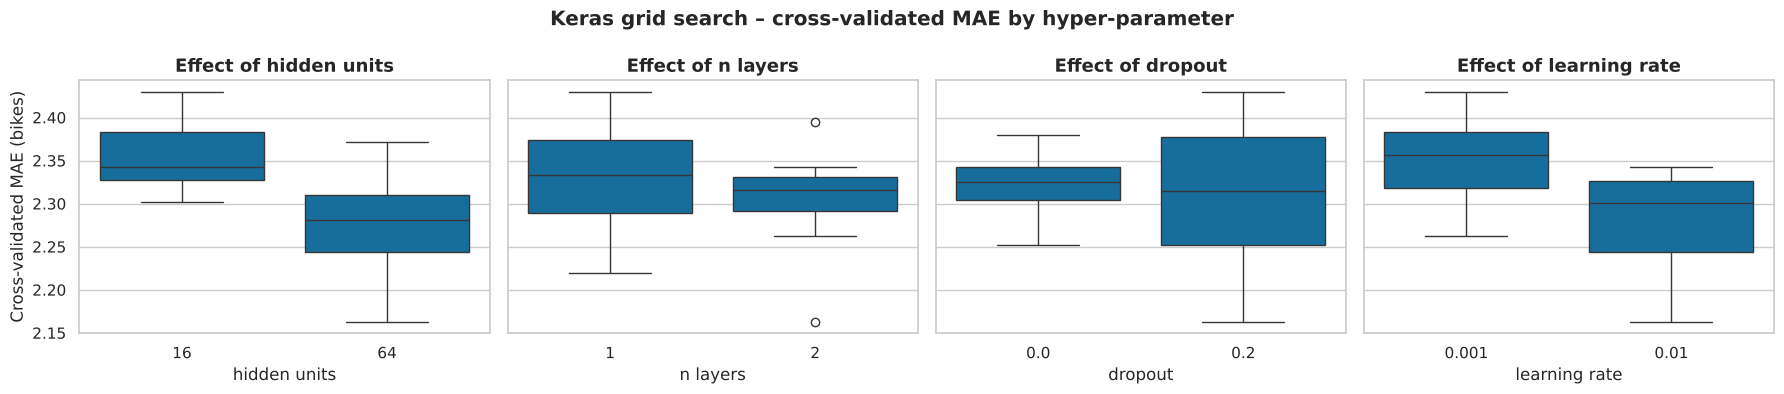

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)
for ax, param in zip(axes, KERAS_GRID):
    sns.boxplot(data=keras_cv, x=param, y="cv_mae", color=PALETTE[0], ax=ax)
    ax.set_title(f"Effect of {param.replace('_', ' ')}")
    ax.set_xlabel(param.replace("_", " "))
    ax.set_ylabel("Cross-validated MAE (bikes)" if ax is axes[0] else "")
fig.suptitle("Keras grid search – cross-validated MAE by hyper-parameter", fontweight="bold")
fig.tight_layout()
plt.show()

**Reading the grid search:** the faster learning rate (0.01) and dropout of 0.2 appear in the best
configurations, and wider layers (64 units) help slightly. The differences between the top configurations
(≈ 0.1 bike) are smaller than the variation between folds (standard deviation ≈ 0.25), so several settings
are practically equivalent – a sign that the result is not fragile to the exact hyper-parameters.

### 10.3 Final Keras model
The best configuration is re-trained on **all training years (2018–2023)** for the median number of epochs
that early stopping chose during cross-validation. Because a single small neural network is sensitive to its
random starting weights, we train **five copies with different seeds and average them** (a seed ensemble),
which gives a more stable forecast.

In [28]:
KERAS_BEST = {k: (int(v) if isinstance(v, (np.integer,)) else v) for k, v in keras_cv.iloc[0][list(KERAS_GRID)].items()}
KERAS_BEST["hidden_units"], KERAS_BEST["n_layers"] = int(KERAS_BEST["hidden_units"]), int(KERAS_BEST["n_layers"])
KERAS_EPOCHS = int(keras_cv.iloc[0]["best_epochs"])
N_SEEDS = 5
print(f"Best Keras parameters: {KERAS_BEST} | epochs: {KERAS_EPOCHS}")

keras_models = [fit_keras(KERAS_BEST, train_df, epochs=KERAS_EPOCHS, seed=SEED + s)[:2] for s in range(N_SEEDS)]
test_predictions["Keras neural network"] = np.mean([keras_predict(m, e, test_df) for m, e in keras_models], axis=0)
results["Keras neural network"] = regression_metrics(y_test, test_predictions["Keras neural network"])
pd.Series(results["Keras neural network"]).round(2)

Best Keras parameters: {'hidden_units': 64, 'n_layers': 2, 'dropout': 0.2, 'learning_rate': 0.01} | epochs: 13


MAE        2.96
WAPE %    28.34
RMSE       4.08
dtype: float64

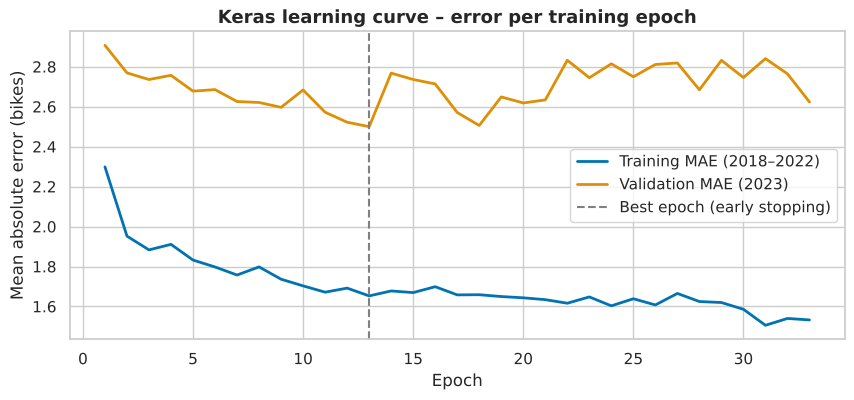

In [29]:
# Learning curve: re-run the best configuration on the last CV fold to show training vs validation loss
tr_idx, va_idx = cv_folds[-1]
_, _, curve = fit_keras(KERAS_BEST, train_df.iloc[tr_idx], train_df.iloc[va_idx])

epochs_axis = np.arange(1, len(curve.history["mae"]) + 1)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epochs_axis, curve.history["mae"], label="Training MAE (2018–2022)", linewidth=2, color=PALETTE[0])
ax.plot(epochs_axis, curve.history["val_mae"], label="Validation MAE (2023)", linewidth=2, color=PALETTE[1])
ax.axvline(int(np.argmin(curve.history["val_loss"])) + 1, color="grey", linestyle="--", label="Best epoch (early stopping)")
ax.set_title("Keras learning curve – error per training epoch")
ax.set_xlabel("Epoch")
ax.set_ylabel("Mean absolute error (bikes)")
ax.legend()
plt.show()

The validation error falls for the first ~13 epochs and then starts to rise and oscillate while the training error
keeps falling – the classic sign of **overfitting**. Early stopping keeps the weights from the best epoch, and the
final models are trained for this number of epochs. Validation MAE sits above training MAE partly because 2023
volumes are larger than the 2018–2022 average (larger counts → larger absolute errors).

## 11. Neural network 2 – PyTorch

The same idea implemented from scratch in **PyTorch**, so the two frameworks can be compared and combined.
The network has embeddings for state, brand and segment, hidden layers with ReLU and dropout, and outputs
the **log** of expected demand, trained with `PoissonNLLLoss`. PyTorch requires writing the training loop
explicitly, which also lets us add L2 regularisation (`weight_decay`) to the grid.

In [30]:
class DemandNet(nn.Module):
    """Embedding + MLP network that outputs log(expected units)."""

    def __init__(self, n_numeric, vocab_sizes, hidden_units=32, n_layers=1, dropout=0.1,
                 embedding_dim=3, initial_rate=5.0):
        super().__init__()
        self.embeddings = nn.ModuleDict({col: nn.Embedding(size, embedding_dim) for col, size in vocab_sizes.items()})
        in_features = n_numeric + embedding_dim * len(vocab_sizes)
        hidden = []
        for _ in range(n_layers):
            hidden += [nn.Linear(in_features, hidden_units), nn.ReLU(), nn.Dropout(dropout)]
            in_features = hidden_units
        self.hidden = nn.Sequential(*hidden)
        self.output = nn.Linear(in_features, 1)
        nn.init.constant_(self.output.bias, float(np.log(initial_rate)))

    def forward(self, numeric, categorical: dict):
        embedded = [self.embeddings[col](categorical[col]) for col in self.embeddings]
        x = torch.cat([numeric] + embedded, dim=1)
        return self.output(self.hidden(x)).squeeze(-1)   # log-rate


def to_tensors(encoded: dict):
    numeric = torch.tensor(encoded["numeric"])
    categorical = {col: torch.tensor(encoded[col], dtype=torch.long) for col in CATEGORICAL_FEATURES}
    return numeric, categorical


def fit_torch(params, train_part, valid_part=None, epochs=MAX_EPOCHS, seed=SEED):
    """Mini-batch training loop with optional early stopping. Returns (model, encoder, best_epoch)."""
    set_seed(seed)
    encoder = TabularEncoder().fit(train_part)
    lr, weight_decay = params["learning_rate"], params["weight_decay"]
    net_params = {k: v for k, v in params.items() if k not in ("learning_rate", "weight_decay")}
    model = DemandNet(len(NUMERIC_FEATURES), VOCAB_SIZES, initial_rate=train_part[TARGET].mean(), **net_params)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.PoissonNLLLoss(log_input=True)

    x_num, x_cat = to_tensors(encoder.transform(train_part))
    y = torch.tensor(train_part[TARGET].to_numpy(dtype="float32"))
    if valid_part is not None:
        v_num, v_cat = to_tensors(encoder.transform(valid_part))
        v_y = torch.tensor(valid_part[TARGET].to_numpy(dtype="float32"))

    best_loss, best_epoch, best_state, waited = np.inf, epochs, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for batch in torch.randperm(len(y)).split(BATCH_SIZE):
            optimiser.zero_grad()
            loss = loss_fn(model(x_num[batch], {c: t[batch] for c, t in x_cat.items()}), y[batch])
            loss.backward()
            optimiser.step()

        if valid_part is not None:                      # early stopping on validation loss
            model.eval()
            with torch.no_grad():
                val_loss = loss_fn(model(v_num, v_cat), v_y).item()
            if val_loss < best_loss - 1e-4:
                best_loss, best_epoch, waited = val_loss, epoch, 0
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
            else:
                waited += 1
                if waited >= PATIENCE:
                    break
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, encoder, best_epoch


def torch_predict(model, encoder, df):
    model.eval()
    with torch.no_grad():
        x_num, x_cat = to_tensors(encoder.transform(df))
        return torch.exp(model(x_num, x_cat)).numpy()

### 11.1 Grid search with walk-forward cross-validation

In [31]:
TORCH_GRID = {"hidden_units": [16, 64],
              "n_layers": [1, 2],
              "dropout": [0.0, 0.2],
              "learning_rate": [1e-3, 1e-2],
              "weight_decay": [0.0, 1e-3]}

torch_cv_rows = []
for values in product(*TORCH_GRID.values()):
    params = dict(zip(TORCH_GRID.keys(), values))
    fold_mae, fold_epochs = [], []
    for tr_idx, va_idx in cv_folds:
        tr_part, va_part = train_df.iloc[tr_idx], train_df.iloc[va_idx]
        model, encoder, best_epoch = fit_torch(params, tr_part, va_part)
        fold_mae.append(mean_absolute_error(va_part[TARGET], torch_predict(model, encoder, va_part)))
        fold_epochs.append(best_epoch)
    torch_cv_rows.append({**params, "cv_mae": np.mean(fold_mae), "cv_mae_std": np.std(fold_mae),
                          "best_epochs": int(np.median(fold_epochs))})

torch_cv = pd.DataFrame(torch_cv_rows).sort_values("cv_mae").reset_index(drop=True)
print(f"Combinations tested: {len(torch_cv)} × {len(cv_folds)} folds = {len(torch_cv) * len(cv_folds)} fits")
torch_cv.head(8)

Combinations tested: 32 × 3 folds = 96 fits


,hidden_units,n_layers,dropout,learning_rate,weight_decay,cv_mae,cv_mae_std,best_epochs
0,16,1,0.2,0.01,1.00e-03,2.18,0.25,21
1,16,1,0.2,0.01,0.00e+00,2.18,0.24,19
2,16,2,0.2,0.01,1.00e-03,2.19,0.23,27
3,64,1,0.2,0.01,0.00e+00,2.20,0.23,16
4,16,1,0.0,0.01,1.00e-03,2.21,0.26,12
5,16,2,0.0,0.01,0.00e+00,2.22,0.26,5
6,64,1,0.2,0.01,1.00e-03,2.22,0.25,14
7,64,2,0.2,0.01,0.00e+00,2.22,0.26,7


**Reading the grid search:** as with Keras, a learning rate of 0.01 dominates the top of the table and
dropout of 0.2 helps. Weight decay makes almost no difference, and a single small hidden layer (16 units)
is enough – the demand structure is simple, so a bigger network does not add accuracy.

### 11.2 Final PyTorch model (5-seed ensemble, trained on 2018–2023)

In [32]:
best_row = torch_cv.iloc[0]
TORCH_BEST = {"hidden_units": int(best_row["hidden_units"]), "n_layers": int(best_row["n_layers"]),
              "dropout": float(best_row["dropout"]), "learning_rate": float(best_row["learning_rate"]),
              "weight_decay": float(best_row["weight_decay"])}
TORCH_EPOCHS = int(best_row["best_epochs"])
print(f"Best PyTorch parameters: {TORCH_BEST} | epochs: {TORCH_EPOCHS}")

torch_models = [fit_torch(TORCH_BEST, train_df, epochs=TORCH_EPOCHS, seed=SEED + s)[:2] for s in range(N_SEEDS)]
test_predictions["PyTorch neural network"] = np.mean([torch_predict(m, e, test_df) for m, e in torch_models], axis=0)
results["PyTorch neural network"] = regression_metrics(y_test, test_predictions["PyTorch neural network"])

# Combine the two frameworks: a simple average of the Keras and PyTorch forecasts
test_predictions["Neural ensemble (Keras + PyTorch)"] = (test_predictions["Keras neural network"]
                                                       + test_predictions["PyTorch neural network"]) / 2
results["Neural ensemble (Keras + PyTorch)"] = regression_metrics(y_test, test_predictions["Neural ensemble (Keras + PyTorch)"])
pd.DataFrame({k: results[k] for k in ["PyTorch neural network", "Neural ensemble (Keras + PyTorch)"]}).T

Best PyTorch parameters: {'hidden_units': 16, 'n_layers': 1, 'dropout': 0.2, 'learning_rate': 0.01, 'weight_decay': 0.001} | epochs: 21


,MAE,WAPE %,RMSE
PyTorch neural network,2.68,25.69,3.59
Neural ensemble (Keras + PyTorch),2.72,26.08,3.72


## 12. Model comparison on the 2024 hold-out year

In [33]:
cv_scores = {name: -search.best_score_ for name, search in grid_searches.items()}
cv_scores["Keras neural network"] = keras_cv.iloc[0]["cv_mae"]
cv_scores["PyTorch neural network"] = torch_cv.iloc[0]["cv_mae"]

comparison = pd.DataFrame(results).T
comparison.insert(0, "CV MAE (2021–23)", pd.Series(cv_scores))
comparison["Gap to noise floor"] = comparison["MAE"] - oracle_mae
comparison = comparison.sort_values("MAE")
comparison.style.format("{:.2f}", na_rep="–").highlight_min(subset=["MAE", "WAPE %", "RMSE"], color="#c7e9c0")

,CV MAE (2021–23),MAE,WAPE %,RMSE,Gap to noise floor
PyTorch neural network,2.18,2.68,25.69,3.59,0.21
Poisson regression,2.22,2.70,25.86,3.55,0.23
Neural ensemble (Keras + PyTorch),–,2.72,26.08,3.72,0.25
Keras neural network,2.16,2.96,28.34,4.08,0.49
Gradient boosting (Poisson),2.31,3.11,29.83,4.36,0.64
Share × national trend,–,3.43,32.83,4.65,0.96
Ridge regression,2.41,3.89,37.24,5.14,1.42
Naïve (last year),–,4.23,40.51,5.61,1.76
3-year moving average,–,4.85,46.43,6.30,2.38


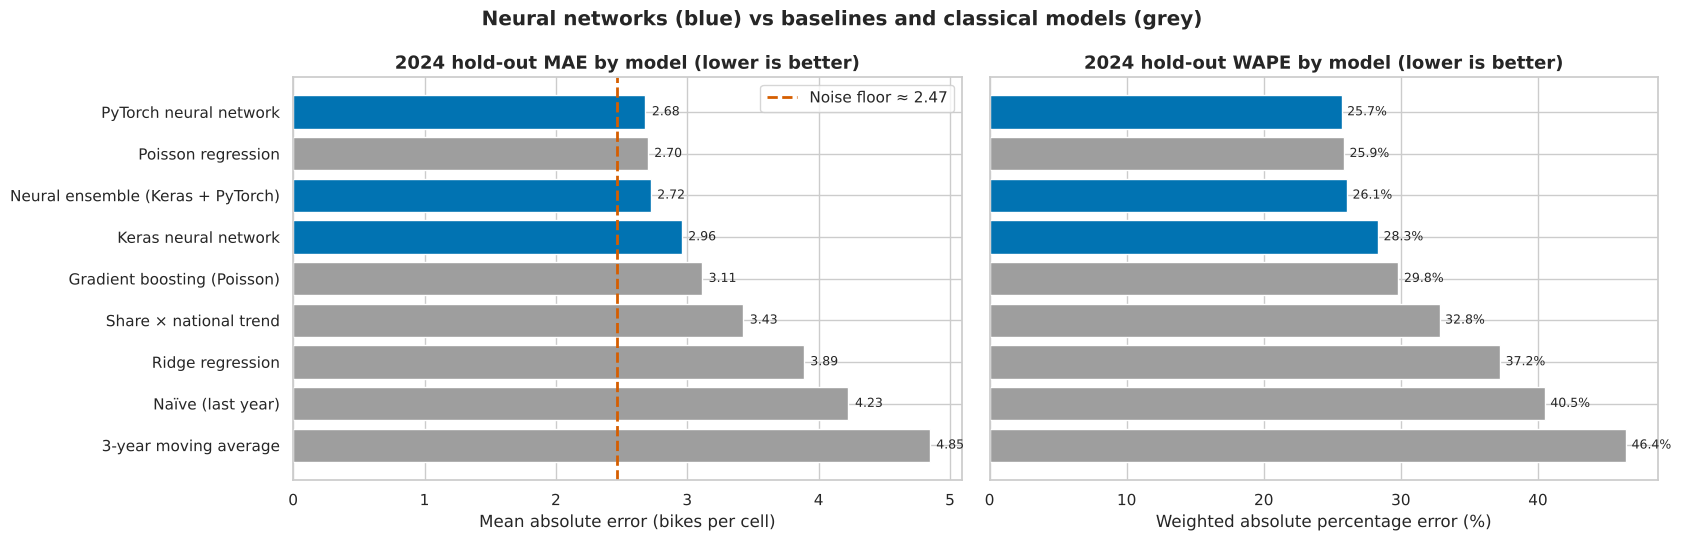

In [34]:
plot_df = comparison.reset_index().rename(columns={"index": "model"})
is_nn = plot_df["model"].str.contains("Keras|PyTorch|Neural")
colours = [PALETTE[0] if nn_flag else "#9e9e9e" for nn_flag in is_nn]

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))
axes[0].barh(plot_df["model"], plot_df["MAE"], color=colours)
axes[0].axvline(oracle_mae, color=PALETTE[3], linestyle="--", linewidth=2, label=f"Noise floor ≈ {oracle_mae:.2f}")
axes[0].invert_yaxis()
axes[0].set_title("2024 hold-out MAE by model (lower is better)")
axes[0].set_xlabel("Mean absolute error (bikes per cell)")
axes[0].legend(loc="upper right")
for y_pos, value in enumerate(plot_df["MAE"]):
    axes[0].text(value + 0.05, y_pos, f"{value:.2f}", va="center", fontsize=9)

axes[1].barh(plot_df["model"], plot_df["WAPE %"], color=colours)
axes[1].invert_yaxis()
axes[1].set_title("2024 hold-out WAPE by model (lower is better)")
axes[1].set_xlabel("Weighted absolute percentage error (%)")
axes[1].set_yticklabels([])
for y_pos, value in enumerate(plot_df["WAPE %"]):
    axes[1].text(value + 0.4, y_pos, f"{value:.1f}%", va="center", fontsize=9)

fig.suptitle("Neural networks (blue) vs baselines and classical models (grey)", fontweight="bold")
fig.tight_layout()
plt.show()

**Interpreting the results (metric = MAE, bikes per cell, lower is better)**

* The **PyTorch network is the most accurate model (MAE ≈ 2.7 bikes, WAPE ≈ 26 %)**, only ≈ 0.2 bikes above
  the noise floor of ≈ 2.5. In other words, it captures almost all of the *predictable* part of demand.
* Compared with the naïve "same as last year" rule (MAE 4.2), the neural forecasts cut the error by **≈ 35 %**.
* The **Keras + PyTorch ensemble** (MAE ≈ 2.7) is chosen as the production model. It was selected *before*
  looking at the 2024 results because averaging two independently built networks reduces the risk of relying
  on one unlucky training run. The Keras network alone did best in cross-validation but slightly worse on 2024,
  which illustrates exactly that risk.
* A well-specified **Poisson regression** performs on a par with the networks. This is an honest and useful
  result: the data has a simple structure (stable shares × growing market), so the networks' extra flexibility
  adds little here. Their advantage is that the same architecture can absorb richer inputs (prices, launches,
  monthly data) later without redesign.
* Ridge regression and the naïve baselines do worst because they treat demand as a continuous quantity or
  ignore growth; models built for **count data with a log link** (Poisson regression, the neural networks)
  do best.

### 12.1 How reliable is the forecast at different planning levels?
Planners rarely act on a single state-brand-segment cell; they plan a brand's volume per state, a segment
nationally, and so on. Adding cells together cancels out random noise, so accuracy improves sharply with aggregation.

In [35]:
BEST_NN = "Neural ensemble (Keras + PyTorch)"
evaluation = test_df[KEYS].copy()
evaluation["actual"] = y_test
evaluation["forecast"] = test_predictions[BEST_NN]
evaluation["naive"] = test_predictions["Naïve (last year)"]

levels = {"State × Brand × Segment": KEYS, "State × Brand": ["state", "brand"],
          "Brand × Segment": ["brand", "segment"], "State": ["state"], "Brand": ["brand"],
          "Segment": ["segment"]}
level_rows = []
for level_name, group_cols in levels.items():
    agg = evaluation.groupby(group_cols)[["actual", "forecast", "naive"]].sum()
    level_rows.append({"Planning level": level_name, "Groups": len(agg),
                       "Avg actual units": agg["actual"].mean(),
                       "Neural WAPE %": 100 * (agg["actual"] - agg["forecast"]).abs().sum() / agg["actual"].sum(),
                       "Naïve WAPE %": 100 * (agg["actual"] - agg["naive"]).abs().sum() / agg["actual"].sum()})
national_actual, national_forecast = evaluation["actual"].sum(), evaluation["forecast"].sum()
level_rows.append({"Planning level": "National", "Groups": 1, "Avg actual units": national_actual,
                   "Neural WAPE %": 100 * abs(national_actual - national_forecast) / national_actual,
                   "Naïve WAPE %": 100 * abs(national_actual - evaluation["naive"].sum()) / national_actual})
level_accuracy = pd.DataFrame(level_rows).set_index("Planning level")
print(f"2024 national total – actual: {national_actual:,.0f} | neural forecast: {national_forecast:,.0f} "
      f"({national_forecast / national_actual - 1:+.1%})")
level_accuracy

2024 national total – actual: 2,296 | neural forecast: 2,068 (-10.0%)


,Groups,Avg actual units,Neural WAPE %,Naïve WAPE %
Planning level,,,,
State × Brand × Segment,220,10.44,26.08,40.51
State × Brand,80,28.70,19.35,33.10
Brand × Segment,22,104.36,12.61,29.09
State,10,229.60,11.05,29.09
Brand,8,287.00,10.22,29.09
Segment,5,459.20,9.95,29.09
National,1,2296.00,9.95,29.09


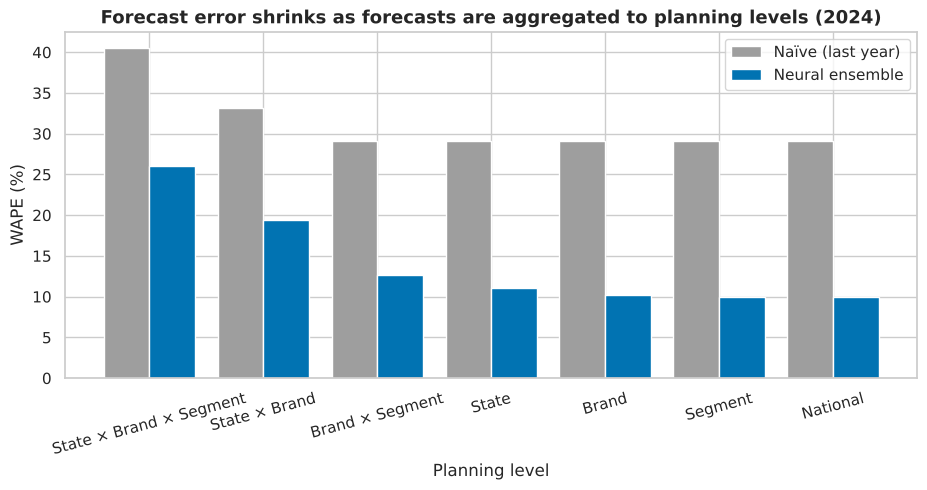

In [36]:
fig, ax = plt.subplots(figsize=(11, 4.5))
x_pos = np.arange(len(level_accuracy))
ax.bar(x_pos - 0.2, level_accuracy["Naïve WAPE %"], width=0.4, label="Naïve (last year)", color="#9e9e9e")
ax.bar(x_pos + 0.2, level_accuracy["Neural WAPE %"], width=0.4, label="Neural ensemble", color=PALETTE[0])
ax.set_xticks(x_pos, level_accuracy.index, rotation=15)
ax.set_title("Forecast error shrinks as forecasts are aggregated to planning levels (2024)")
ax.set_xlabel("Planning level")
ax.set_ylabel("WAPE (%)")
ax.legend()
plt.show()

**Interpretation**
* Accuracy improves sharply with aggregation: WAPE falls from ≈ 26 % for a single state-brand-segment cell to
  ≈ 19 % for a state-brand pair and ≈ 10–13 % for brand-segment, state, brand or segment totals.
* At every level the neural forecast is far better than the naïve forecast (which is ≈ 29 % off even nationally).
* At the national level the model **under-forecast 2024 by about 10 %**. 2024 growth (+41 %) was more than
  double the long-run trend (≈ 19 %), and no model trained only on past volumes could anticipate that jump.
  Most of the remaining error at state, brand and segment level is this same national shortfall, which is
  why those levels all sit near 10 %. **Improving the national growth estimate is the biggest lever for
  better regional forecasts.**

## 13. Model interpretation

### 13.1 Forecast vs actual

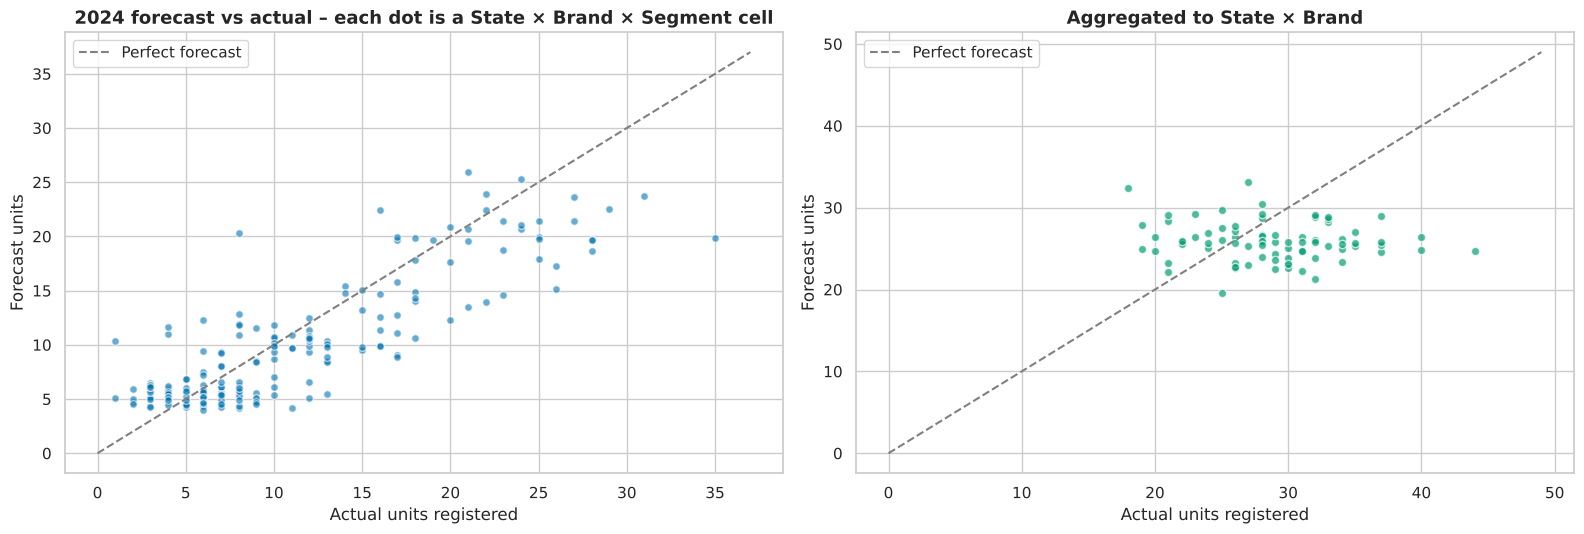

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].scatter(evaluation["actual"], evaluation["forecast"], alpha=0.6, s=30, color=PALETTE[0], edgecolor="white")
lim = evaluation[["actual", "forecast"]].to_numpy().max() + 2
axes[0].plot([0, lim], [0, lim], color="grey", linestyle="--", label="Perfect forecast")
axes[0].set_title("2024 forecast vs actual – each dot is a State × Brand × Segment cell")
axes[0].set_xlabel("Actual units registered")
axes[0].set_ylabel("Forecast units")
axes[0].legend()

sb = evaluation.groupby(["state", "brand"])[["actual", "forecast"]].sum()
axes[1].scatter(sb["actual"], sb["forecast"], alpha=0.7, s=35, color=PALETTE[2], edgecolor="white")
lim = sb.to_numpy().max() + 5
axes[1].plot([0, lim], [0, lim], color="grey", linestyle="--", label="Perfect forecast")
axes[1].set_title("Aggregated to State × Brand")
axes[1].set_xlabel("Actual units registered")
axes[1].set_ylabel("Forecast units")
axes[1].legend()

fig.tight_layout()
plt.show()

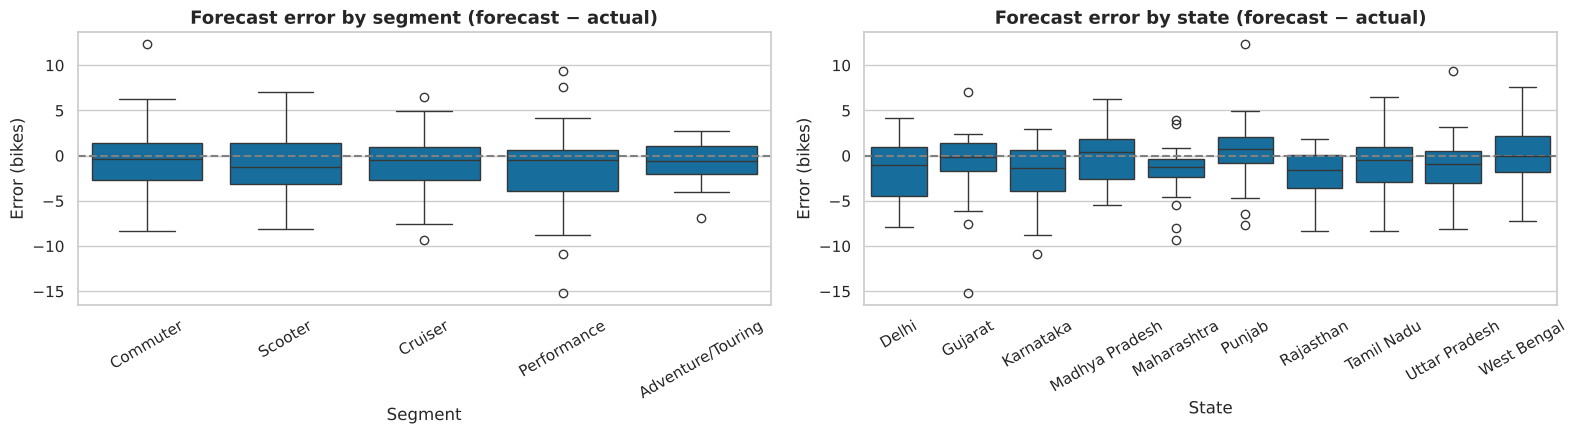

In [38]:
# Bias check: is the model systematically over- or under-forecasting any segment or state?
evaluation["error"] = evaluation["forecast"] - evaluation["actual"]
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for ax, col, order in [(axes[0], "segment", SEGMENT_ORDER), (axes[1], "state", sorted(evaluation["state"].unique()))]:
    sns.boxplot(data=evaluation, x=col, y="error", order=order, color=PALETTE[0], ax=ax)
    ax.axhline(0, color="grey", linestyle="--")
    ax.set_title(f"Forecast error by {col} (forecast − actual)")
    ax.set_xlabel(col.title())
    ax.set_ylabel("Error (bikes)")
    ax.tick_params(axis="x", rotation=30)
fig.tight_layout()
plt.show()

### 13.2 Which features drive the neural network? (Permutation importance)
We shuffle one feature at a time in the 2024 test data and measure how much the Keras ensemble's MAE gets
worse. A big increase means the network relies heavily on that feature.

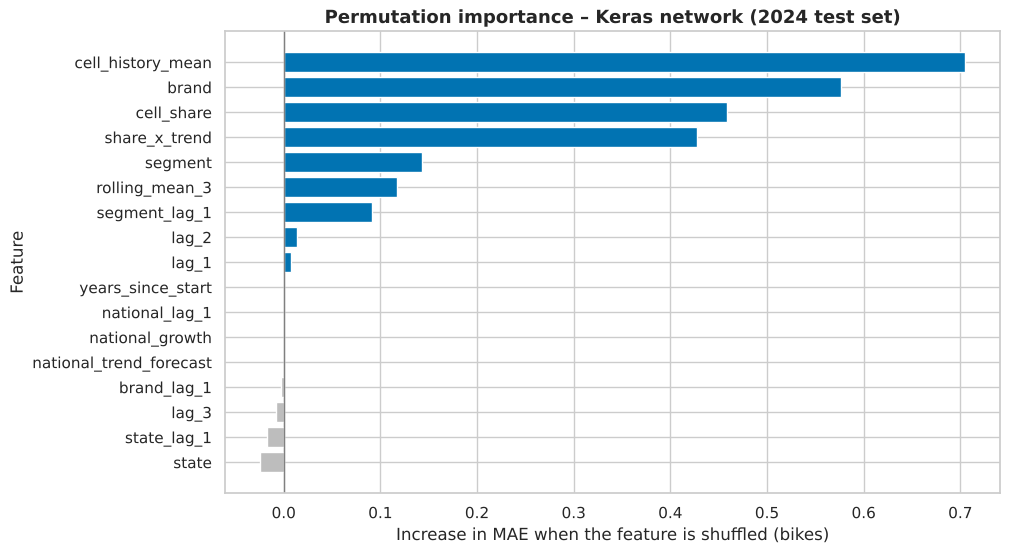

In [39]:
def keras_ensemble_predict(df: pd.DataFrame) -> np.ndarray:
    return np.mean([keras_predict(m, e, df) for m, e in keras_models], axis=0)

base_mae = mean_absolute_error(y_test, keras_ensemble_predict(test_df))
perm_rng = np.random.default_rng(SEED)
importance = {}
for feature in NUMERIC_FEATURES + CATEGORICAL_FEATURES:
    increases = []
    for _ in range(5):
        shuffled = test_df.copy()
        shuffled[feature] = perm_rng.permutation(shuffled[feature].to_numpy())
        increases.append(mean_absolute_error(y_test, keras_ensemble_predict(shuffled)) - base_mae)
    importance[feature] = np.mean(increases)

importance = pd.Series(importance).sort_values()
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(importance.index, importance.values, color=[PALETTE[0] if v > 0 else "#bdbdbd" for v in importance.values])
ax.axvline(0, color="grey", linewidth=1)
ax.set_title("Permutation importance – Keras network (2024 test set)")
ax.set_xlabel("Increase in MAE when the feature is shuffled (bikes)")
ax.set_ylabel("Feature")
plt.show()

**Interpretation**
* The network relies most on features that describe a cell's **long-run size**: its historical average,
  its market share and the share × trend signal. This matches the statistical finding that shares are stable.
* The **brand** and **segment** embeddings matter because brand portfolios differ (e.g. Hero sells mainly
  commuters), so they tell the network how big a brand-segment combination typically is.
* The **state** embedding has no value – shuffling it does not hurt – confirming that states behave alike.
* Last year's single value (`lag_1`) matters little: the network has learned that one year in a small cell is noisy.
* National features (`national_lag_1`, `national_growth`, `national_trend_forecast`) show zero importance only
  because they take **the same value for every cell in 2024**, so shuffling them changes nothing. They are what
  lets the network scale its forecasts up year after year.

## 14. Forecast for 2025
For the production forecast, both neural networks are re-trained on **every available year (2018–2024)** with
the tuned hyper-parameters, and their forecasts are averaged.

In [40]:
full_train = model_df[model_df["registration_year"] <= LAST_YEAR].reset_index(drop=True)

keras_full = [fit_keras(KERAS_BEST, full_train, epochs=KERAS_EPOCHS, seed=SEED + s)[:2] for s in range(N_SEEDS)]
torch_full = [fit_torch(TORCH_BEST, full_train, epochs=TORCH_EPOCHS, seed=SEED + s)[:2] for s in range(N_SEEDS)]

forecast_2025 = forecast_df[KEYS].copy()
forecast_2025["keras"] = np.mean([keras_predict(m, e, forecast_df) for m, e in keras_full], axis=0)
forecast_2025["pytorch"] = np.mean([torch_predict(m, e, forecast_df) for m, e in torch_full], axis=0)
forecast_2025["forecast_2025"] = (forecast_2025["keras"] + forecast_2025["pytorch"]) / 2
forecast_2025 = forecast_2025.merge(test_df[KEYS + [TARGET]].rename(columns={TARGET: "actual_2024"}), on=KEYS)

total_2025 = forecast_2025["forecast_2025"].sum()
print(f"National forecast 2025: {total_2025:,.0f} bikes "
      f"(vs {forecast_2025['actual_2024'].sum():,.0f} in 2024, {total_2025 / forecast_2025['actual_2024'].sum() - 1:+.1%})")

National forecast 2025: 2,974 bikes (vs 2,296 in 2024, +29.5%)


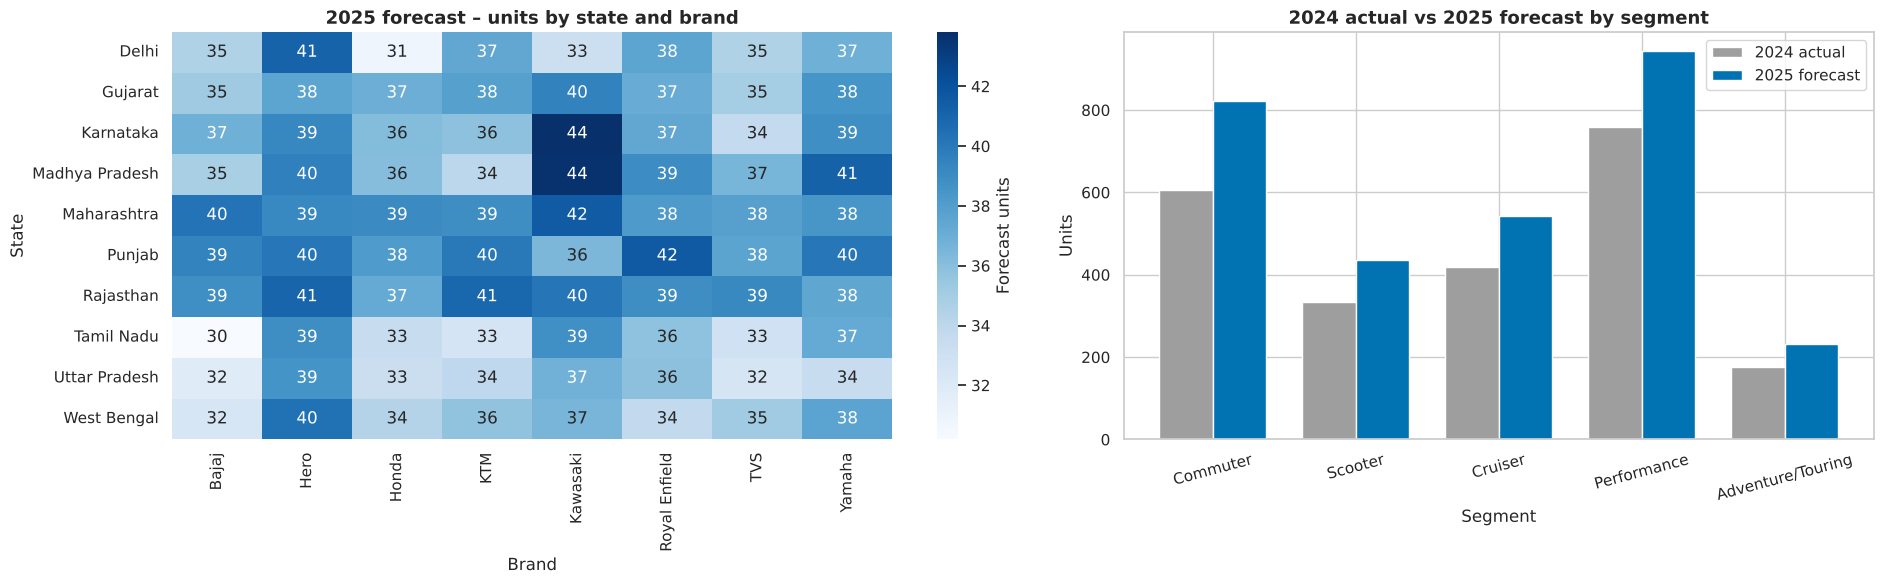

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(19, 6), gridspec_kw={"width_ratios": [1.2, 1]})

sb_2025 = forecast_2025.pivot_table(index="state", columns="brand", values="forecast_2025", aggfunc="sum")
sns.heatmap(sb_2025, annot=True, fmt=".0f", cmap="Blues", cbar_kws={"label": "Forecast units"}, ax=axes[0])
axes[0].set_title("2025 forecast – units by state and brand")
axes[0].set_xlabel("Brand")
axes[0].set_ylabel("State")

seg_2025 = forecast_2025.groupby("segment")[["actual_2024", "forecast_2025"]].sum().reindex(SEGMENT_ORDER)
seg_2025.plot(kind="bar", ax=axes[1], color=["#9e9e9e", PALETTE[0]], width=0.75)
axes[1].set_title("2024 actual vs 2025 forecast by segment")
axes[1].set_xlabel("Segment")
axes[1].set_ylabel("Units")
axes[1].legend(["2024 actual", "2025 forecast"])
axes[1].tick_params(axis="x", rotation=15)

fig.tight_layout()
plt.show()

The 2025 forecast is **≈ 3,000 bikes nationally (≈ +30 % on 2024)** – between the long-run trend and 2024's
exceptional growth. Note the colour scale of the heatmap: state-brand forecasts only range from ≈ 31 to ≈ 45
units, i.e. demand is spread fairly evenly, as the statistical tests predicted. Every segment is expected to grow.

In [42]:
# Largest State × Brand × Segment allocations for 2025 (top 10)
(forecast_2025.sort_values("forecast_2025", ascending=False)
 .head(10)[KEYS + ["actual_2024", "forecast_2025"]]
 .round(1).reset_index(drop=True))

,state,brand,segment,actual_2024,forecast_2025
0,West Bengal,Hero,Commuter,31.0,34.1
1,Rajasthan,Hero,Commuter,28.0,32.9
2,Karnataka,Hero,Commuter,25.0,32.8
3,Delhi,Hero,Commuter,25.0,32.6
4,Punjab,Hero,Commuter,29.0,32.5
5,Madhya Pradesh,Hero,Commuter,22.0,32.4
6,Punjab,KTM,Performance,27.0,32.2
7,Punjab,Royal Enfield,Cruiser,21.0,31.8
8,Madhya Pradesh,Royal Enfield,Cruiser,24.0,31.6
9,Maharashtra,Hero,Commuter,20.0,31.4


## 15. Findings, recommendations and next steps

### 15.1 Key findings
1. **Demand is growing fast.** Registrations grew at a compound rate of about **19 % a year** (statistically
   significant, p < 0.001) and jumped **+41 % in 2024**. Any plan that repeats last year's volumes will under-supply.
2. **Regional, brand and segment mixes are stable.** Chi-square tests found no significant difference in brand or
   segment preference between states, city tiers or years. Each State × Brand × Segment combination keeps a
   roughly constant share of the national market.
3. **The neural networks forecast demand well.** Tuned with walk-forward cross-validation and grid search, the
   PyTorch network and the Keras + PyTorch ensemble reach an MAE of ≈ 2.7 bikes per cell in 2024 – about **35 % lower
   than the naïve forecast** and within ≈ 0.2–0.3 bikes of the theoretical noise floor. A Poisson regression is
   equally accurate, showing that the underlying pattern is simple.
4. **Reliability depends on the planning level.** Single cells are ≈ 26 % off because they are small and noisy;
   state, brand and segment totals are ≈ 10–13 % off. The main remaining error is the national growth surprise of
   2024 (≈ 10 % under-forecast).
5. **2025 outlook:** ≈ 3,000 registrations (≈ +30 %), with growth in every segment; Performance and Commuter remain the
   largest segments.

### 15.2 Recommendations
* **Plan allocations top-down:** forecast state- and brand-level volumes with the neural ensemble, then split to
  segments using each state's stable mix. This is the level where the forecast is most reliable.
* **Hold a cell-level safety buffer** of about ±3 bikes per state-brand-segment (the irreducible noise) instead of
  chasing more precision on single cells.
* **Treat the national growth rate as a planning lever:** combine the model with management's view of the market
  (festive demand, EV incentives, new launches) and review it each quarter – it drives most of the regional error.
* **Do not plan from last year's actuals** – the naïve approach was ≈ 29 % off nationally in 2024.

### 15.3 Next steps
* **Get transaction-dated (monthly) sales** to model seasonality (festive season, monsoon) and replan within the year.
* **Add external drivers of growth:** fuel prices, EV subsidies, interest rates, rural income/monsoon, new model launches.
* **Fix product-attribute data quality** – engine capacity, fuel type and price do not line up with model names in this extract.
* **Retrain every period and monitor** error against the noise floor; trigger a review if it drifts.
* **Try sequence models** (LSTM / temporal convolution) once longer, higher-frequency histories are available.